**Análisis de SuperStore Analytics** | [Repositorio en GitHub](https://github.com/Edvard-Pichardo/superstore-analytics)

Análisis exploratorio y de negocio realizado con Python y pandas,
utilizando las vistas analíticas generadas previamente en MySQL.

## Nuestros objetivos para este Notebook son:

- Reproducir los principales análisis desarrollados en SQL.
- Realizar análisis exploratorio con pandas.
- Generar visualizaciones con matplotlib.
- Validar consistencia entre distintas vistas analíticas.
- Identificar patrones comerciales, de clientes, productos,
  geografía y logística.
- Exportar tablas y gráficos como resultados del proyecto.


## **Preparación**

Antes de hacer gráficos y entender los diferentes KPIs del negocio al que pertenece la base de datos, debemos preparar el terreno para importar nuestros datos hacia nuestro Notebook y poder utilizarlos sin que haya ningún problema, lo que significa importar datos y revisar que cada uno de ellos esté definido en el tipo correcto de datos.

Deberíamos hacer otras comprobaciones como que los nombres de las columnas de nuestra base de datos estén normalizados, la calidad de los datos, las faltas de ortográficas y demás, pero no será tan necesario en esta ocasión porque vamos a importar dos *views* que ya generamos antes en SQL.

Esto es importante porque significa que tendremos una base de datos limpia, que nos permita todas las facilidades para trabajar con ella.

In [208]:
# Importamos librerías que vamos a utilizar a lo largo del documento.

# Importamos Path para trabajar con rutas de archivos de forma independiente del sistema operativo.
from pathlib import Path

# Ocultamos advertencias que no sean relevantes para el análisis.
import warnings
warnings.filterwarnings("ignore")

# Importamos herramientas principales para análisis numérico y manipulación de datos.
import numpy as np
import pandas as pd

# Importamos matplotlib para crear las visualizaciones.
import matplotlib.pyplot as plt

# Importamos funciones para mostrar DataFrames de forma cómoda dentro de Google Colab / Jupyter.
from IPython.display import display

In [209]:
# También es importante establecer algunas condiciones de entorno.

# Configuramos pandas para mostrar más columnas cuando sea necesario.
pd.set_option("display.max_columns", 100)

# Configuramos el número máximo de filas visibles.
pd.set_option("display.max_rows", 100)

# Configuramos la presentación de números decimales.
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)

In [210]:
# Nuestras bases de datos se encuentran en un repositorio de GitHub (en el que estoy guardando el proyecto)

# Borramos la carpeta antes de clonar (en caso de que esté anteriormente)
!rm -rf superstore-analytics

# Clonamos el repositorio de GitHub porque ahí se encuentran las bases de datos
!git clone https://github.com/Edvard-Pichardo/superstore-analytics.git

Cloning into 'superstore-analytics'...
remote: Enumerating objects: 377, done.
remote: Counting objects: 100% (377/377), done.
remote: Compressing objects: 100% (238/238), done.
remote: Total 377 (delta 227), reused 279 (delta 135), pack-reused 0 (from 0)
Receiving objects: 100% (377/377), 2.29 MiB | 10.48 MiB/s, done.
Resolving deltas: 100% (227/227), done.


In [211]:
# Definimos la ruta exacta indicada para los CSV de las views.
RUTA_BASE = "superstore-analytics/data/views/"

# Convertimos la cadena anterior en un objeto Path.
RUTA_BASE = Path(RUTA_BASE)

# Comprobamos que la carpeta exista.
if not RUTA_BASE.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta: {RUTA_BASE}"
    )
print(
    "Carpeta de datos:",
    RUTA_BASE
)

Carpeta de datos: superstore-analytics/data/views


In [212]:
# Buscamos todos los archivos CSV dentro de la carpeta.
archivos_csv = sorted(RUTA_BASE.glob("*.csv"))
if not archivos_csv:
    raise FileNotFoundError("No se encontraron archivos CSV en la carpeta de views.")
print(f"Se encontraron {len(archivos_csv)} archivos:\n")
for archivo in archivos_csv:
    print("-", archivo.name)

Se encontraron 11 archivos:

- vw_business_overview.csv
- vw_category_performance.csv
- vw_customer_performance.csv
- vw_geographic_performance.csv
- vw_monthly_performance.csv
- vw_order_summary.csv
- vw_product_performance.csv
- vw_sales_detail.csv
- vw_segment_performance.csv
- vw_ship_mode_performance.csv
- vw_subcategory_performance.csv


In [213]:
# Definamos una función para cargar los CSVs

def cargar_csv(ruta):
    """
    Carga un archivo CSV.
    Primero intenta utilizar UTF-8 con BOM.
    Si la codificación no funciona, intenta latin-1.

    Parámetros:
      ruta : Path
        Ruta del archivo CSV.

    Retorna:
      pandas.DataFrame
        DataFrame con los datos cargados.
    """
    try:
        return pd.read_csv(ruta, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(ruta, encoding="latin-1")

In [214]:
# Cargamos los CSV

# Los guardaremos en un diccionario donde:
# clave = nombre de la view
# valor = DataFrame correspondiente

views = {}

for archivo in archivos_csv:
    # Eliminamos ".csv" para quedarnos solamente con el nombre de la view.
    nombre_view = archivo.stem
    # Cargamos el archivo.
    dataframe = cargar_csv(archivo)
    # Lo guardamos en el diccionario.
    views[nombre_view] = dataframe
    print(f"{nombre_view:<35}" f"{dataframe.shape[0]:>7,} filas x " f"{dataframe.shape[1]:>2} columnas")

vw_business_overview                     1 filas x 32 columnas
vw_category_performance                  3 filas x 19 columnas
vw_customer_performance                800 filas x 22 columnas
vw_geographic_performance              616 filas x 22 columnas
vw_monthly_performance                  48 filas x 18 columnas
vw_order_summary                     5,113 filas x 26 columnas
vw_product_performance               1,891 filas x 20 columnas
vw_sales_detail                     10,194 filas x 25 columnas
vw_segment_performance                   3 filas x 23 columnas
vw_ship_mode_performance                 5 filas x 24 columnas
vw_subcategory_performance              17 filas x 15 columnas


In [215]:
# En general, utilizaremos dos views para nuestros análisis.
VISTA_DETALLE = "vw_sales_detail"
VISTA_PEDIDOS = "vw_order_summary"

# Creamos los dataframes principales
sales_detail = views[VISTA_DETALLE].copy()
order_summary = views[VISTA_PEDIDOS].copy()

print("vw_sales_detail:", sales_detail.shape)
print("vw_order_summary:", order_summary.shape)

vw_sales_detail: (10194, 25)
vw_order_summary: (5113, 26)


In [216]:
# Veamos su estructura. Para ello, imprimimos las columnas de sales_detail
print("Columnas de sales_detail")
for columna in sales_detail.columns:
    print("-", columna)

Columnas de sales_detail
- order_detail_key
- source_row_id
- order_key
- order_id
- order_date
- ship_date
- shipping_days
- ship_mode
- customer_id
- customer_name
- segment
- country
- state
- city
- postal_code
- region
- product_key
- product_id
- product_name
- category
- sub_category
- sales
- quantity
- discount
- profit


In [217]:
# Imprimimos las columnas de order_summary
print("Columnas de order_summary")

for columna in order_summary.columns:
    print("-", columna)

Columnas de order_summary
- order_key
- order_id
- order_date
- order_year
- order_month
- order_year_month
- ship_date
- shipping_days
- ship_mode
- customer_id
- customer_name
- segment
- country
- state
- city
- postal_code
- region
- total_order_lines
- distinct_products
- total_sales
- total_quantity
- average_line_discount
- total_profit
- unknown_sales_lines
- unknown_quantity_lines
- unknown_profit_lines


In [218]:
# Antes de analizar nuestros datos, debemos convertir el tipo de datos de algunos de ellos.
# Especialmente a los que corresponden a fechas y datos numéricos.

# Convertimos las fechas
for dataframe in [sales_detail, order_summary]:
    for columna in ["order_date", "ship_date"]:
        if columna in dataframe.columns:
            dataframe[columna] = pd.to_datetime(
                dataframe[columna],
                errors="coerce",
            )

# Variables numéricas de order_details
columnas_numericas_detalle = [
    "shipping_days",
    "sales",
    "quantity",
    "discount",
    "profit",
    "product_key",
    "order_key"
]
for columna in columnas_numericas_detalle:
    if columna in sales_detail.columns:
        sales_detail[columna] = pd.to_numeric(sales_detail[columna], errors="coerce")

# Variables numéricas de order_summary
columnas_numericas_pedidos = [
    "shipping_days",
    "total_order_lines",
    "distinct_products",
    "total_sales",
    "total_quantity",
    "average_line_discount",
    "total_profit",
    "unknown_sales_lines",
    "unknown_quantity_lines",
    "unknown_profit_lines"
]
for columna in columnas_numericas_pedidos:
    if columna in order_summary.columns:
        order_summary[columna] = pd.to_numeric(order_summary[columna], errors="coerce")

print("Tipos de datos convertidos correctamente.")

Tipos de datos convertidos correctamente.


In [219]:
# Vamos a hacer un análisis sobre la calidad de nuestros datos en ambas tablas.
# Aquí lo importante es notar que estamos trabajando con datos anteriormente procesados y que están limpios
# es decir, todos los problemas que la base de datos original traía han sido trabajados.
# Pero es importante hacer este reporte para ver que los datos tengan su tipo bien especificado, comprobar los valores nulos y
# los valores únicos de cada columna.

def reporte_calidad(df):
    """
    Genera un resumen de calidad para cada columna.
    """
    resultado = pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[col].dtype) for col in df.columns],
        "rows": [len(df) for _ in df.columns],
        "nulls": [df[col].isna().sum() for col in df.columns],
        "distinct_values": [df[col].nunique(dropna=True) for col in df.columns]
    })
    return resultado.sort_values("nulls", ascending=False)

In [220]:
print("Calidad de sales_detail")
calidad_detalle = reporte_calidad(sales_detail)
display(calidad_detalle)


Calidad de sales_detail


,column,dtype,rows,nulls,distinct_values
24,profit,float64,10194,498,7044
21,sales,float64,10194,468,5620
7,ship_mode,object,10194,280,4
22,quantity,float64,10194,188,23
0,order_detail_key,int64,10194,0,10194
4,order_date,datetime64[ns],10194,0,1242
1,source_row_id,int64,10194,0,10194
3,order_id,object,10194,0,5111
2,order_key,int64,10194,0,5113
8,customer_id,object,10194,0,800


In [221]:
print("Calidad de order_summary")
calidad_pedidos = reporte_calidad(order_summary)
display(calidad_pedidos)

Calidad de order_summary


,column,dtype,rows,nulls,distinct_values
8,ship_mode,object,5113,274,4
19,total_sales,float64,5113,118,4427
22,total_profit,float64,5113,108,4665
20,total_quantity,float64,5113,51,114
1,order_id,object,5113,0,5111
3,order_year,int64,5113,0,4
5,order_year_month,object,5113,0,48
2,order_date,datetime64[ns],5113,0,1242
4,order_month,int64,5113,0,12
0,order_key,int64,5113,0,5113


In [222]:
# Ahora, vamos a válidar que no existan duplicados en sales_detail
# Esto lo hicimos en SQL, pero podemos replicarlo aquí.

print("Filas en vw_sales_detail:", len(sales_detail))
print("Filas duplicadas exactas:", sales_detail.duplicated().sum())
print("Pedidos distintos:", sales_detail["order_id"].nunique())
print("Clientes distintos:", sales_detail["customer_id"].nunique())

Filas en vw_sales_detail: 10194
Filas duplicadas exactas: 0
Pedidos distintos: 5111
Clientes distintos: 800


In [223]:
# Otra de las cosas que necesitamos es una función que se encarge de crear tablas de resumen
# calculando los KPIs de nuestra base de datos.

def agregar_metricas(
    df,
    columnas_grupo,
    columna_pedidos="order_id",
    columna_clientes="customer_id",
    columna_ventas="sales",
    columna_cantidad="quantity",
    columna_beneficio="profit"):
    """
    Calcula las principales métricas comerciales agrupadas por una o varias dimensiones.
    Si columnas_grupo está vacío, calcula los totales globales.
    """

    # C1: Si no hay columnas de grupo, hacemos una agregación global manual.
    if not columnas_grupo:
        resultado = pd.DataFrame({
            "orders": [df[columna_pedidos].nunique()],
            "customers": [df[columna_clientes].nunique()],
            "sales": [df[columna_ventas].sum()],
            "quantity": [df[columna_cantidad].sum()],
            "profit": [df[columna_beneficio].sum()]
        })

    # C2: Si hay columnas de grupo, hacemos el groupby normal
    else:
        resultado = (df.groupby(columnas_grupo, dropna=False).agg(
                orders=(columna_pedidos, "nunique"),
                customers=(columna_clientes, "nunique"),
                sales=(columna_ventas, "sum"),
                quantity=(columna_cantidad, "sum"),
                profit=(columna_beneficio, "sum")).reset_index())

    # El margen se calcula a partir de los totales (aplica para ambos casos)
    resultado["profit_margin_percentage"] = np.where(
        resultado["sales"] != 0,
        resultado["profit"] / resultado["sales"] * 100,
        np.nan
    )
    return resultado

In [224]:
# Vamos a probar nuestra función generando un reporte ejecutivo general

business = agregar_metricas(sales_detail, columnas_grupo=[])
business["average_order_value"] = (business["sales"]/business["orders"])
# display(business.T) #Esto nos da una tabla con los datos globales solicitados.

In [225]:
# Tomemos los datos anteriores y diseñemos una tabla de presentación ejecutiva.
kpis = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Distinct Customers",
        "Total Quantity",
        "Total Sales",
        "Total Profit",
        "Profit Margin",
        "Average Order Value"],

    "Value": [
        business.loc[0, "orders"],
        business.loc[0, "customers"],
        business.loc[0, "quantity"],
        business.loc[0, "sales"],
        business.loc[0, "profit"],
        business.loc[0, "profit_margin_percentage" ],
        business.loc[0, "average_order_value"]]
})
display(kpis)

,KPI,Value
0,Total Orders,"5,111.00"
1,Distinct Customers,800.00
2,Total Quantity,"68,296.00"
3,Total Sales,"2,156,775.10"
4,Total Profit,"146,888.02"
5,Profit Margin,6.81
6,Average Order Value,421.99


In [226]:
# Bien. Ahora, vamos a crear una función capaz de guardar gráficos.
# Esto no es necesario para el análisis, pero me servirá para guardar los gráficos generados más adelante.

# Definimos la ruta en la que queremos guardar los gráficos:
RUTA_GRAFICOS = Path("superstore-analytics/images/")

def guardar_grafico(nombre_archivo):
    """
    Guarda la figura actual dentro de la carpeta de gráficos del proyecto.
    """
    ruta = RUTA_GRAFICOS / nombre_archivo
    plt.tight_layout()
    plt.savefig(ruta, dpi=200, bbox_inches="tight")
    print("Gráfico guardado en: ", ruta)

# **Análisis de datos**

## **Análisis por Tiempo**

Una vez completada la fase de limpieza, estructuración y validación de los datos, se procede al análisis de negocio. El primer paso metodológico consiste en establecer una línea base mediante la comparación de las métricas globales de ingresos y rentabilidad. Esto permite dimensionar el volumen total de la operación y evaluar la eficiencia general del negocio antes de desglosar los datos por dimensiones específicas.

Esta evaluación inicial se centra en las métricas agregadas fundamentales: ventas totales (`sales`), beneficio (`profit`), volumen de pedidos (`orders`) y valor medio del pedido. Dado que sales representa el ingreso bruto y profit la ganancia neta (o beneficio neto) tras costos, la comparación entre ambas magnitudes revela la proporción de los ingresos que se convierte efectivamente en ganancia, estableciendo así el punto de partida para identificar ineficiencias operativas.

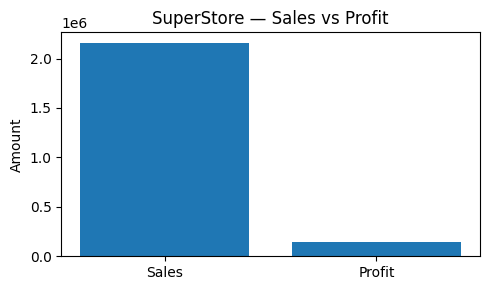

In [227]:
# Graficamos sales vs profit para ver cómo se han comportado a lo largo de los cuatro años que corresponde a nuestra base de datos.

datos_general = pd.DataFrame({
    "Metric": ["Sales","Profit"],
    "Value": [sales_detail["sales"].sum(), sales_detail["profit"].sum()]
})

# Creamos la figura.
plt.figure(figsize=(5, 3))

# Dibujamos las dos métricas.
plt.bar(datos_general["Metric"], datos_general["Value"])

# Título y etiquetas.
plt.title("SuperStore — Sales vs Profit")
plt.xlabel(""), plt.ylabel("Amount")
plt.tight_layout()

plt.show()

El gráfico de barras compara las dos métricas de mayor relevancia en el negocio durante todo el periodo de análisis. Los valores agregados son:

- Ventas Totales (Sales) $≈$ $2,156,775

- Beneficio Total (Profit) $≈$ $146,888

La diferencia visual entre ambas barras es un indicador directo de la estructura de costos del negocio. El beneficio representa aproximadamente el 6.8% de las ventas totales $\left(\dfrac {$146,888}{ $2,156,775} * 100\right)$. Esto implica que, en promedio, de cada 100 dólares vendidos, la empresa retiene solo 6.80 dólares como ganancia neta.

Ahora, la disparidad visual no es un error ni una anomalía en sí misma; simplemente refleja que el negocio opera con un margen de beneficio bajo. La relevancia de esta métrica radica en la magnitud de ese margen.

Un margen global del $6.8$% es considerado bajo en términos de eficiencia operativa. Esta cifra agregada, sin embargo, es un promedio que puede ocultar tanto áreas de alta rentabilidad como áreas de pérdida significativa. La brecha observada justifica el análisis subsecuente a nivel granular (categorías, subcategorías, descuentos, regiones), ya que el resultado global es la suma de rendimientos dispares.

El objetivo de los siguientes apartados será identificar las variables que erosionan este margen del $6.8$%. La atención se centrará en detectar productos con márgenes negativos recurrentes, categorías con alta densidad de descuentos o regiones con costos logísticos que absorben la rentabilidad de las ventas.

### **Análisis Anual**

El análisis acumulado del negocio a lo largo del tiempo puede enmascarar variaciones críticas en el rendimiento operativo. Por ello, este apartado se desglosará la evolución año tras año de los KPIs principales: ventas (sales), beneficio (profit) y margen de beneficio (profit_margin_percentage).

El objetivo es evaluar la progresión del negocio y determinar si el crecimiento en volumen de ventas se traduce en un aumento proporcional de la rentabilidad. Es fundamental establecer esta distinción, ya que un incremento en los ingresos no garantiza una mejora en la eficiencia operativa; un mayor volumen de ventas puede coexistir con una disminución significativa del margen, indicando una pérdida de rentabilidad subyacente.

In [228]:
# Grafiquemos las ventas por año.
# Recordemos que el periodo de la base de datos cubre 2023, 2024, 2025 y 2026.

# Aseguramos que tengamos una columna de año.
sales_detail["year"] = (sales_detail["order_date"].dt.year)

# Agrupamos por año.
annual = (sales_detail.groupby("year").agg(
        orders=("order_key","nunique"),
        customers=("customer_id","nunique"),
        sales=("sales", "sum"),
        quantity=("quantity", "sum"),
        profit=("profit", "sum"))
    .reset_index().sort_values("year")
)

# Calculamos el margen anual.
annual["profit_margin_percentage"] = (annual["profit"] / annual["sales"] * 100)

# Calculamos variación interanual de ventas.
annual["sales_yoy_percentage"] = (annual["sales"].pct_change() * 100)

# Calculamos variación interanual de beneficio.
annual["profit_yoy_percentage"] = (annual["profit"].pct_change() * 100)

display(annual)

,year,orders,customers,sales,quantity,profit,profit_margin_percentage,sales_yoy_percentage,profit_yoy_percentage
0,2023,996,605,"469,225.89","14,304.00","28,528.38",6.08,NaN,NaN
1,2024,1053,577,"449,334.91","15,719.00","32,924.23",7.33,-4.24,15.41
2,2025,1340,650,"556,828.74","18,860.00","17,501.55",3.14,23.92,-46.84
3,2026,1724,700,"681,385.56","19,413.00","67,933.85",9.97,22.37,288.16


En la tabla podemos observar como las ventas cayeron un $4.24$% en 2024, pero la ganancia aumentó un $15.41$% respecto al año anterior. Esto es interesante porque significa que, aunque las ventas disminuyeron, no fue importante para mantener un rango de ganancia o beneficio amplio.

En cambio, en 2025 aumentaron las ventas un $23.92$% respecto a 2024, pero el beneficio cayó hasta casi la mitad de lo que se había conseguido.

Después la empresa se recuperó cuando en 2026 aumentaron las ventas en un $23.92$% y también la genancia en un $288.16$%, lo que habla de una recuperación y una mejora en cuánto a la rentabilidad de las ventas.

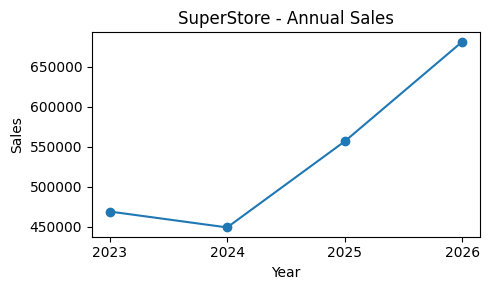

In [229]:
# Podemos ver la tendencia temporal mediante un gráfico y, de esa forma, ver de una manera más sencilla el crecimiento,
# estabilidad, cambios bruscos o caídas.

plt.figure(figsize=(5, 3))

plt.plot(annual["year"], annual["sales"], marker="o")
plt.title("SuperStore - Annual Sales")
plt.xlabel("Year"), plt.ylabel("Sales")
plt.xticks(annual["year"])
plt.tight_layout()

plt.show()

El gráfico muestra una contracción inicial del $-4.24$% en 2024, seguida de un crecimiento acelerado y sostenido en 2025 con el $+23.92$% y en 2026 con el $+22.37$%.

Este crecimiento en los dos últimos años indica una estrategia de expansión de volumen, sin embargo, el gráfico de ventas por sí solo no es suficiente para evaluar la salud del negocio, ya que no refleja si ese mayor volumen de ingresos se está traduciendo en ganancias reales.


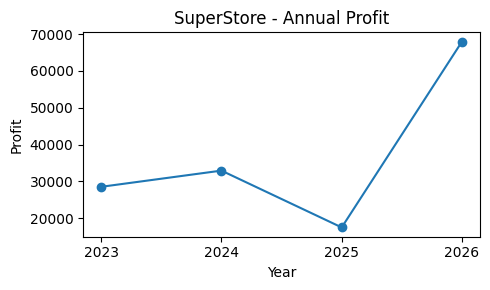

In [230]:
# Por ello, ahora vamos a gráficar las ganancias anuales.
plt.figure(figsize=(5, 3))

plt.plot(annual["year"], annual["profit"],marker="o")
plt.title("SuperStore - Annual Profit")
plt.xlabel("Year"), plt.ylabel("Profit")
plt.xticks(annual["year"])
plt.tight_layout()

plt.show()

Observemos que el beneficio muestra una divergencia significativa respecto a las ventas. En 2024, el beneficio aumentó un $+15.41$% a pesar de la caída en ventas. En 2025, ocurre lo contrario, el beneficio se desplomó un $-46.84$% mientras las ventas crecían. En 2026, por alguna razón que todavía desconocemos, el beneficio se disparó un $+288.16$%.

La caída del beneficio en 2025 es un indicador directo de ineficiencia operativa. La empresa aumentó sus ventas, pero destruyó más de la mitad de su ganancia, lo que sugiere un aumento desproporcionado en costos variables o una política de descuentos agresiva que anuló el margen, esto podríamos descfubrirlo analizando esas métricas directamente. La recuperación de 2026 indica una corrección estructural en la operación.

Gráfico guardado en:  superstore-analytics/images/01_annual_sales_vs_profit.png


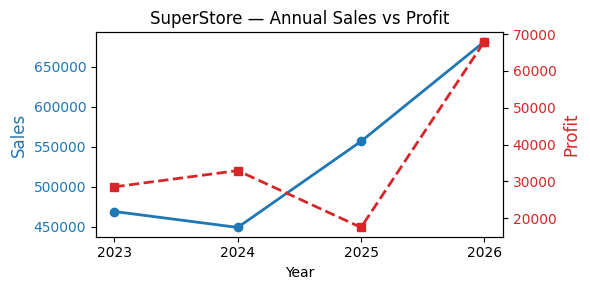

In [231]:
# Ahora, podemos superponer ambos gráficos para observar ese comportamiento de mejor manera.

fig, ax1 = plt.subplots(figsize=(6, 3))

# Ventas (Línea Azul)
color_ventas = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Sales', color=color_ventas, fontsize=12)
ax1.plot(
    annual["year"],
    annual["sales"],
    marker="o",
    color=color_ventas,
    linewidth=2,
    label="Sales"
)
ax1.tick_params(axis='y', labelcolor=color_ventas)
ax1.set_xticks(annual["year"])

# Beneficio (Línea Roja Discontinua)
ax2 = ax1.twinx()  # Crea un segundo eje Y que comparte el mismo eje X
color_beneficio = 'tab:red'
ax2.set_ylabel('Profit', color=color_beneficio, fontsize=12)
ax2.plot(
    annual["year"],
    annual["profit"],
    marker="s",
    color=color_beneficio,
    linestyle="--",
    linewidth=2,
    label="Profit"
)
ax2.tick_params(axis='y', labelcolor=color_beneficio)

# Título y formato
plt.title("SuperStore — Annual Sales vs Profit")
fig.tight_layout()

guardar_grafico("01_annual_sales_vs_profit.png")
plt.show()

Al superponer ambas métricas con ejes independientes, se visualiza la divergencia de 2025. Mientras la línea de ventas (azul) asciende, la línea de beneficio (roja) cae en picada. En 2026, ambas líneas convergen al alza, con la línea de beneficio creciendo a un ritmo muy superior.

Una vez más, esto es evidencia de que el crecimiento en ventas no es sinónimo de rentabilidad. El año 2025 representó un punto de inflexión negativo donde el volumen de ventas ocultó una crisis de ganancias. La recuperación de 2026 demuestra que la empresa logró alinear su crecimiento en volumen con una mejora sustancial en su eficiencia.

Para continuar, recordemos que definimos el margen como:

$$
\text{margin} = \frac{\text{profit}}{\text{sales}}
$$

Esto nos permitirá comparar la rentabilidad relativa entre años, ya que esta es la métrica más crítica para evaluar la eficiencia operativa de una empresa porque que aísla la rentabilidad del volumen de ventas.

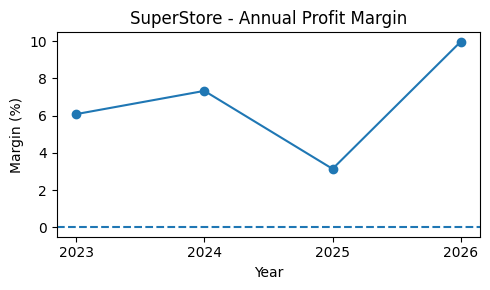

In [232]:
# Graficamos el margen anual.
plt.figure(figsize=(5, 3))

plt.plot(annual["year"], annual["profit_margin_percentage"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("SuperStore - Annual Profit Margin")
plt.xlabel("Year"), plt.ylabel("Margin (%)")
plt.xticks(annual["year"])
plt.tight_layout()

plt.show()

El gráfico muestra la evolución del margen de beneficio anual. Podemos notar que:

- 2023 ($6.08$%): Este nuestro punto de partida. Notemos que existe un margen bajo pero positivo.

- 2024 ($7.33$%): El margen mejoró de 1.25 puntos porcentuales. Esto quiere decir que la empresa logró ser más eficiente, convirtiendo una mayor proporción de sus ingresos en ganancias.

- 2025 ($3.14$%): Este es un punto de contracción porque el margen cayó 4.19 puntos porcentuales. A pesar de que las ventas crecieron un 23.9% ese año, la toma de alguna decisión o algún factor que todavía no hemos análizado  destruyeron más de la mitad de la rentabilidad relativa de la empresa.

- 2026 ($9.97$%): Aquí podemos notar una muy buena recuperación. El margen se disparó 6.83 puntos porcentuales, superando el 5% del Business Overview global. Esto indica una optimización drástica, quizá mejorando lo que se hizo mal un año anterior o siendo más estrictos con algunas reglas internas de la compañia.

Podemos interpretar que el crecimiento en ventas de 2025 no fue sostenible porque no venía acompañado de rentabilidad y que la recuperación de 2026 fue el resultado de una corrección estructural en la operación, más no solo de un aumento en el volumen de las ventas.

### **Análisis Mensual**

El análisis anual permite evaluar la tendencia macro del negocio, pero puede ocultar variaciones críticas en la operación. Este análisis mensual tiene como objetivo desglosar el comportamiento de los KPIs (`sales`, `profit` y `profit_margin_percentage`) para identificar patrones de estacionalidad, detectar meses con pérdidas operativas y aislar anomalías que expliquen las fluctuaciones anuales.

Se busca correlacionar el volumen de actividad (orders, quantity) con la rentabilidad efectiva mes a mes.

In [233]:
# Primero generamos la tabla con las ventas, cantidad, ganancias y margen de cada mes durante los años de operación.
sales_detail["year_month"] = (sales_detail["order_date"].dt.to_period("M").astype(str))

monthly = (sales_detail.groupby("year_month").agg(
        orders=("order_key", "nunique"),
        sales=("sales", "sum"),
        quantity=("quantity", "sum"),
        profit=("profit", "sum")).reset_index()
)

monthly["profit_margin_percentage"] = (monthly["profit"] / monthly["sales"] * 100)

display(monthly)

,year_month,orders,sales,quantity,profit,profit_margin_percentage
0,2023-01,33,"13,647.27",303.00,"2,492.70",18.27
1,2023-02,28,"4,497.67",159.00,897.17,19.95
2,2023-03,72,"56,376.33","1,060.00",534.69,0.95
3,2023-04,66,"27,692.19","1,066.00","3,248.97",11.73
4,2023-05,72,"22,943.95",887.00,"2,157.61",9.40
5,2023-06,67,"33,238.79",512.00,"2,758.49",8.30
6,2023-07,65,"33,731.44",945.00,"-4,554.11",-13.50
7,2023-08,75,"28,349.74","1,641.00","2,222.03",7.84
8,2023-09,134,"74,538.71","1,543.00","7,296.08",9.79
9,2023-10,82,"29,977.16","1,385.00","2,241.62",7.48


A diferencia del análisis anual, donde las tendencias macro son visibles, el análisis mensual requiere un mayor nivel de detalle debido al volumen de datos. Esto lo haremos con gráficos, pero también podemos analizar una cierta tendencia de patrones convirtiendo el dataframe en una tabla interactiva.

En primer lugar, existe una concentración sistemática de altos volúmenes de ventas en los meses de noviembre y diciembre de cada año. Tenemos, por ejemplo, noviembre del 2026 registró \$104445 en ventas, seguido de diciembre del 2025 que registró \$91754. A simple vista se puede notar que los meses entre septiembre y dociembre de todos los años se presenta una mayor venta que en otros meses.

A pesar del incremento en el volumen de pedidos y unidades vendidas en estos meses, el beneficio no escala proporcionalmente. En varios años, este aumento de actividad coincide con márgenes negativos o significativamente reducidos.

A lo largo de los 48 meses analizados, se pueden identificar múltiples periodos donde el beneficio fue negativo, destruyendo valor a pesar de tener ventas positivas, por ejemplo:

- 2023: Jul (-\$4,554.11; -13.50%).
- 2024: Ene (-\$3,096.02; -16.78%), Sep (-\$8,193.55; -13.13%).

Para facilitar la interpretación de estos 48 periodos, se necesita construir un gráfico de tendencia mensual de ventas. Esta representación visual permite detectar de forma inmediata la concentración de actividad en determinados meses, la recurrencia de caídas y la progresión general del negocio, estableciendo así la base para análisis posteriores de rentabilidad y estacionalidad.


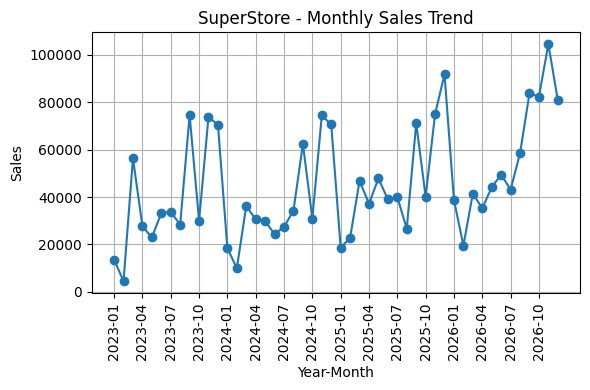

In [234]:
# Grafiquemos la tendencia mensual de ventas.
plt.figure(figsize=(6, 4))

plt.plot(monthly["year_month"], monthly["sales"], marker="o")
plt.title("SuperStore - Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")

# Para evitar saturar el eje X, mostramos una etiqueta aproximadamente cada tres meses.
posiciones = list(range(0, len(monthly), 3))

plt.xticks(posiciones, monthly.loc[posiciones,"year_month"], rotation=90)
plt.tight_layout()
plt.grid(True)

plt.show()

El gráfico de líneas representa la evolución de las ventas mensuales a lo largo de 46 meses (enero 2023 a octubre 2026).

Se puede identificar una tendencia subyacente ascendente. El rango de ventas se ha expandido significativamente. En 2023 los picos oscilaban entre los $70,000$ y $75,000$; para 2026, los picos superan los $100,000$ (con un máximo histórico en noviembre de 2026 de aproximadamente $104,000$).

El volumen base del negocio es notablemente superior. Los valles de 2026 son considerablemente más altos que los valles de 2023.

Además, se pueden identificar dos periodos clave de alta actividad:

- **Septiembre:** Un pico secundario pero consistente en todos los años (2023: $∼$74,500; 2024: $∼$62,300; 2025: $∼$71,000; 2026: $∼$83,600).

- **Noviembre / Diciembre:** La concentración de ventas en el último trimestre es un patrón fijo. En 2025, diciembre alcanzó $∼$91,700, y en 2026, noviembre y diciembre combinados sumaron más de 185,000.

Y dos periodos de baja actividad:

- **Enero / Febrero:** Son los meses de menor actividad de forma sistemática. Esto es indicativo de una contracción post-temporada navideña.Por ejemplo, en 2024, febrero cayó a un mínimo de $∼$9,900.

- **Abril / Mayo:** Se observa una caída secundaria después del repunte de marzo.

Los datos presentan una alta volatilidad mes a mes. Como se puede observar, las transiciones de valle a pico son abruptas. Esta irregularidad esto puede tener diversas explicaciones, aunque considero que sugiere que el negocio no tiene un flujo de ingresos constantes, sino que depende de campañas específicas, ventas de comercios o compañías específicas o temporadas.

In [235]:
# Ahora, hagamos el análisis de estacionalidad, es decir, si el numéro de ventas se comporta similar año con año

sales_detail["month_number"] = (sales_detail["order_date"].dt.month)

seasonality = (sales_detail.groupby("month_number").agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_key", "nunique"))
    .reset_index())

display(seasonality)

,month_number,sales,profit,orders
0,1,"89,460.40","4,888.04",185
1,2,"56,825.72","7,102.07",162
2,3,"180,850.62","25,671.98",362
3,4,"130,676.08","7,716.45",345
4,5,"144,749.38","18,294.17",377
5,6,"146,006.61","10,881.44",369
6,7,"144,207.61","9,219.44",340
7,8,"147,766.31","16,606.39",349
8,9,"291,709.28","17,744.75",702
9,10,"183,349.37","6,168.51",429


Notese que existe una estacionalidad clara y dominante en el último trimestre del año:

- Noviembre (327,549.54 en ventas, 755 pedidos).

- Diciembre (313,624.18 en ventas, 738 pedidos).

- Septiembre (291,709.28 en ventas, 702 pedidos).

Donde noviembre y diciembre destacan como los picos principales y septiembre como el secundario.

En cambio, los valles principales son durante el primer trimestre:

- Enero (89,460.40 en ventas, 185 pedidos).

- Febrero (56,825.72 en ventas, 162 pedidos).

El resto del año se mantiene un volumen relativamente estable, oscilando entre 130,000 y 180,000 en ventas y entre 340 y 377 pedidos. Este bloque representa la operación base del negocio.

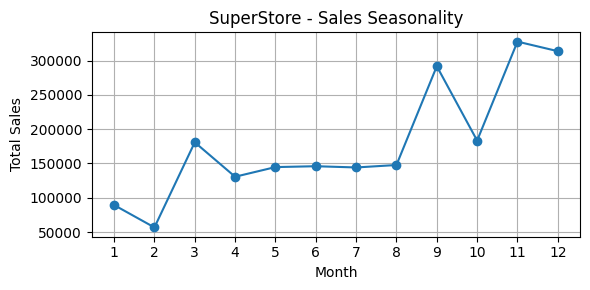

In [236]:
# Grafiquemos la estacionalidad

plt.figure(figsize=(6, 3))

plt.plot(seasonality["month_number"], seasonality["sales"], marker="o")
plt.title("SuperStore - Sales Seasonality")
plt.xlabel("Month"), plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.grid(True)

plt.show()


El gráfico de líneas representa el perfil estacional de las ventas totales por número de mes (1 al 12), consolidando los cuatro años de datos.

Se remarca que los meses septiembre, **noviembre** y **diciembre** representan una mayor densidad de ventas que, sumados, representan una proporción muy superior al 40% del volumen total anual.

Mientras que la baja actividad se concentra en el primer trimestre, siendo **enero** y **febrero** los de menor contribución. La caída de febrero es la más crítica, representando menos de la mitad del volumen de un mes promedio de la meseta central.

El resto del año se mantiene en estabilidad, exceptuando a  marzo que experimenta un salto abrupto en el número de ventas. Fuera de ello, este periodo no presenta picos ni mesetas lo que sugiere que son las ventas generales o ventas base del negocio.

## **Análisis por Categoría**

Una vez establecida la evolución temporal y el perfil de estacionalidad, es necesario desglosar el negocio para identificar qué componentes del catálogo están impulsando o erosionando los resultados globales. El análisis temporal agregado puede ocultar ineficiencias internas dentro de la estructura de productos.

Este apartado segmenta las métricas por categoría (`category`), evaluando el volumen de ventas, la rentabilidad absoluta y el margen de beneficio relativo. El objetivo es aislar el rendimiento de cada línea de negocio para determinar cuáles son rentables por sí mismas y cuáles, a pesar de generar altos ingresos, están destruyendo valor para la empresa.

In [237]:
# Realizamos el dataframe con los datos de categoría
category = (sales_detail.groupby("category").agg(
        orders=("order_key", "nunique"),
        customers=("customer_id", "nunique"),
        sales=("sales", "sum"),
        quantity=("quantity", "sum"),
        profit=("profit","sum")
    ).reset_index()
)

category["profit_margin_percentage"] = (category["profit"] / category["sales"] * 100)

category = category.sort_values("sales", ascending=False)

display(category)

,category,orders,customers,sales,quantity,profit,profit_margin_percentage
2,Technology,1560,687,"755,221.50","12,993.00","97,577.97",12.92
0,Furniture,1821,713,"706,380.74","14,306.00","-20,902.81",-2.96
1,Office Supplies,3814,793,"695,172.85","40,997.00","70,212.85",10.10


La tabla desglosa el desempeño del negocio en sus tres categorías principales, ordenadas por volumen de ventas. Los datos revelan una heterogeneidad significativa en la rentabilidad de cada línea de producto.

`Technology` es la categoría más rentable en términos absolutos y relativos. Genera el mayor beneficio (\$97.5k) con el margen más alto (12.92%). Su volumen de ventas es el más alto (\$755k), pero con una cantidad de unidades vendidas moderada (12,993), lo que indica un alto valor unitario por producto. Es el principal pilar de la rentabilidad del negocio.

`Office Supplies`, en cambio, es la categoría con mayor actividad transaccional porque concentra el mayor número de pedidos (3,814) y clientes (793), así como el mayor volumen de unidades vendidas (40,997).

A pesar de tener el menor ingreso por ventas (\$695k) debido a su bajo valor unitario, mantiene un buen margen del 10.10% y un beneficio significativo (\$70.2k). Su relevancia radica en la capacidad de atraer y retener clientes.

El problema inicia con `Furniture`, ya que genera un volumen de ventas muy alto (\$706k), similar al de technology, pero opera con pérdidas netas. El margen negativo (-2.96%) indica que los costos operativos, logísticos o los descuentos aplicados superan los ingresos.

Ahora, veamos que el beneficio total del negocio (\$146,888.01) es el resultado de la suma algebraica de las tres categorías:

- Technology: +\$97,577.97

- Office Supplies: +\$70,212.85

- Furniture: -\$20,902.81

Lo que da un total de \$146,888.01

Sin la carga negativa de la categoría `furniture`, el beneficio de la empresa sería de \$167,790.82, un 14.2% superior al actual.

Furniture no solo es improductiva, sino que está absorbiendo parte de la rentabilidad generada por las otras dos categorías.

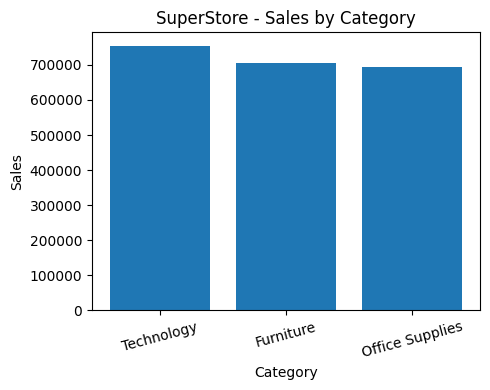

In [238]:
# Visualicemos el tamaño efectivo de cada categoría
plt.figure(figsize=(5, 4))

plt.bar(category["category"], category["sales"])
plt.title("SuperStore - Sales by Category")
plt.xlabel("Category"), plt.ylabel("Sales")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()


Este gráfico de barras compara el volumen total de ventas (`sales`) de las tres categorías principales del negocio. Esta visualización representa exclusivamente la métrica de ingresos brutos (top-line), sin considerar los costos o el beneficio neto.

Las tres barras presentan alturas muy similares, sin diferencias visualmente significativas.

De nuestro dataframe, se tiene que `technology` lidera con \$755,221.50, seguido de `furniture` con \$706,380.74 y `office supplies` con \$695,172.85.

La diferencia entre la categoría con mayores ventas (`technology`) y la de menores ventas (`office supplies`) es de aproximadamente \$60,000, lo que representa una variación de apenas el 8.6%. En términos de ingresos brutos, el negocio está altamente diversificado y ninguna categoría domina el volumen total de ventas.

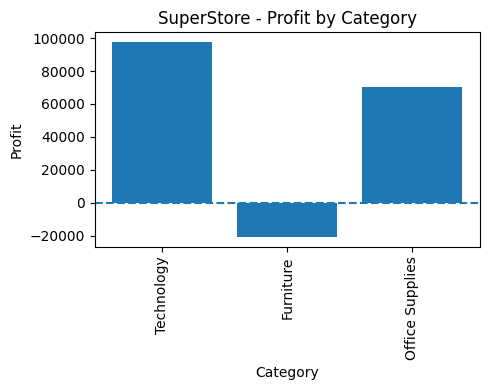

In [239]:
# Grafiquemos el profit por categoría

plt.figure(figsize=(5, 4))

plt.bar(category["category"], category["profit"])
plt.axhline(0, linestyle="--")
plt.title("SuperStore - Profit by Category")
plt.xlabel("Category"), plt.ylabel("Profit")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

Este gráfico de barras representa el beneficio neto absoluto (`profit`) generado por cada una de las tres categorías principales.

Se puede notar que `technology` es la categoría con mayor contribución absoluta al beneficio, alcanzando aproximadamente \$97,500. Su volumen de ventas (\$755k) se traduce de manera eficiente en ganancias netas.

`Office supplies` ocupa el segundo lugar en generación de valor, con un beneficio cercano a los \$70,200. A pesar de tener el menor volumen de ventas de las tres categorías (\$695k), logra una contribución significativa al beneficio total.

En cambio, lo más importante a destacar es la categoría `furniture` porque es la única que se sitúa por debajo de la línea de cero, registrando una pérdida de aproximadamente -\$20,900. Este resultado indica que la operación de esta línea de productos no cubre sus costos asociados (adquisición, logística, almacenamiento) ni los descuentos aplicados.Lo mismo que vimos en la tabla, cada venta realizada en esta categoría reduce el beneficio neto de la empresa.

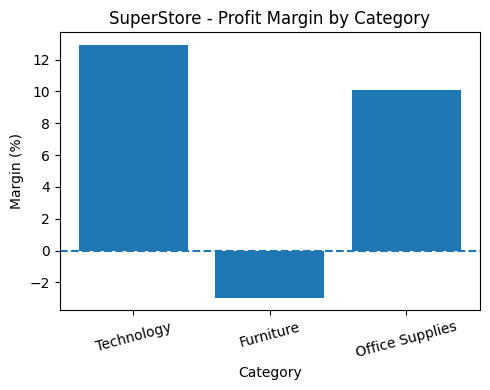

In [240]:
# Grafiquemos el margen por categoría
plt.figure(figsize=(5, 4))

plt.bar(category["category"], category["profit_margin_percentage"])
plt.axhline(0, linestyle="--")
plt.title("SuperStore - Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Margin (%)")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

El gráfico de barras representa el margen de beneficio porcentual (profit_margin_percentage) de cada categoría. A diferencia de los gráficos anteriores, este normaliza la rentabilidad respecto al volumen de ventas, permitiendo comparar la eficiencia operativa relativa de cada línea de negocio independientemente de su tamaño.

De esta forma, se puede estar seguros que tanto `technology` como `office supplies` son sostenibles y rentables a través del tiempo. En cambio,  la categoría `furniture` es la única con un margen negativo. Esto significa que, en promedio, cada venta realizada en esta categoría genera una pérdida neta.

Notemos que el problema de `furniture` no está relacionado a las ventas realizadas porque, de hecho, vende más que `technology`.

La relevancia técnica radica en que cualquier estrategia de mejora del margen global de la empresa debe centrarse en corregir la economía de furniture, ya sea ajustando precios, renegociando costos con proveedores o modificando su política de descuentos.

### **Análisis de Subcategoría**

El análisis a nivel de categoría puede ocultar ineficiencias internas dentro de una misma línea de producto. En este apartado se realiza un desglose a nivel de subcategoría (`subcategory`) con el objetivo de aislar el rendimiento individual de los 17 componentes del catálogo.

El propósito es identificar subcategorías que, incluso dentro de categorías rentables, están destruyendo valor, así como evaluar en profundidad las causas estructurales que explican el margen negativo de la categoría furniture.

In [241]:
# Realizamos nuestro dataframe con las subcategorías

subcategory = (sales_detail.groupby(["category", "sub_category"]).agg(
        orders=("order_key", "nunique"),
        customers=("customer_id", "nunique"),
        products=("product_key", "nunique"),
        sales=("sales", "sum"),
        quantity=("quantity", "sum"),
        profit=("profit", "sum")
        ).reset_index()
)

subcategory["profit_margin_percentage"] = (subcategory["profit"] / subcategory["sales"] * 100)
subcategory = subcategory.sort_values("sales", ascending=False)

display(subcategory)

,category,sub_category,orders,customers,products,sales,quantity,profit,profit_margin_percentage
16,Technology,Phones,826,511,189,"317,056.76","5,774.00","26,539.71",8.37
1,Furniture,Chairs,591,408,88,"311,201.55","4,581.00","13,372.48",4.30
11,Office Supplies,Storage,787,514,133,"216,336.53","5,423.00","10,312.71",4.77
3,Furniture,Tables,314,261,57,"196,314.84","2,271.00","-25,749.69",-13.12
6,Office Supplies,Binders,1339,651,213,"191,677.15","10,884.00","-5,915.32",-3.09
15,Technology,Machines,114,99,64,"172,782.65",964.00,"-9,284.27",-5.37
13,Technology,Accessories,718,474,147,"162,186.57","6,016.00","30,782.37",18.98
0,Furniture,Bookcases,228,196,50,"108,560.15","1,163.00","-13,979.26",-12.88
14,Technology,Copiers,70,64,13,"103,195.52",239.00,"49,540.15",48.01
4,Office Supplies,Appliances,459,356,99,"103,135.70","2,369.00","16,145.57",15.65


La tabla desglosa las métricas del negocio en 17 subcategorías, ordenadas por volumen de ventas descendente. Se tiene que identificar los generadores de beneficio y los destructores de valor, evaluando tanto el impacto absoluto como la eficiencia relativa (margen).

A primera vista, se encuentra que el problema de `furniture` radica en las  pérdidas concentradas en dos de sus subcategorías, especificamente **tables** y **bookcases**. Notese que:

- **Tables:** Con \$196,314.84 en ventas (la cuarta más alta), genera una pérdida de **-\$25,749.69** (margen: -13.12%). Este es el mayor destructor de valor absoluto de todo el catálogo.

- **Bookcases:** Con \$108,560.15 en ventas, genera una pérdida de **-\$13,979.26** (margen: -12.88%), el segundo mayor destructor.

A pesar de que `furniture` en su conjunto pierde -\$20,902.81, las subcategorías de **chairs** (4.30% margen) y furnishings (6.04% margen) son rentables.

Entonces, tenemos que el déficit de `furniture` no es un problema generalizado de la categoría, sino de dos subcategorías específicas (**tables** y **bookcases**) cuyas pérdidas combinadas (-\$39,728.95) superan con creces las ganancias de chairs y furnishings. Corregir estas dos líneas eliminaría el lastre financiero de toda la categoría.

También, se puede notar un desempeño variado en `technology`. La subcategoría **copiers** es la subcategoría más rentable en términos relativos, con un margen de 48.01% (\$49,540.15 de beneficio). Otra que también destaca es **accessories** con un margen de 18.98% (\$30,782.37 de beneficio).

Hay un problema con la subcategoría **machines**, ya que genera una pérdida de **-\$9,284.27** (margen: -5.37%) a pesar de tener \$172,782.65 en ventas. Este resultado negativo en una subcategoría de alto ticket promedio absorbe gran parte de la rentabilidad generada por copiers y accessories, impidiendo que `technology` alcance un margen global superior al 12.92%.

**Phones** es el mayor generador de ventas y el segundo mayor generador de beneficio (\$26,539.71). Sin embargo, su margen es relativamente bajo (8.37%), lo que indica que es un producto de alto volumen y alta rotación, pero con una estructura de costos o descuentos que limita su eficiencia.

También, notese que la categoría `office supplies` es la más consistente. Destacan **paper** (41.28% margen), **labels** (38.81%), **envelopes** (39.06%) y **art** (20.02%). Estos productos son de bajo costo unitario, pero de alta rotación.

Al igual que en las otras categorías, hay excepciones. **Binders** genera una pérdida de **-\$5,915.32** (margen: -3.09%) a pesar de ser el quinto mayor volumen de ventas de todo el catálogo. **Supplies** también presenta un margen ligeramente negativo (-2.72%).

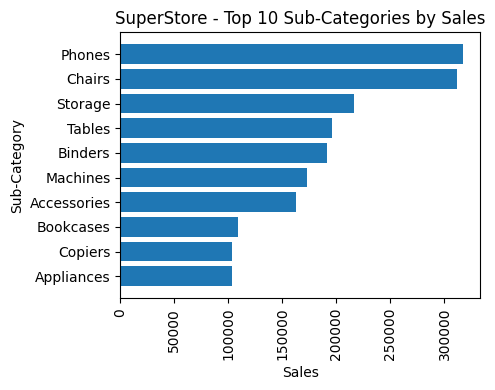

In [242]:
# Se revisa el top 10 de subcategorías por número de ventas
top_subcategories = (subcategory.nlargest(10,"sales").sort_values("sales"))

plt.figure(figsize=(5, 4))

plt.barh(top_subcategories["sub_category"], top_subcategories["sales"])
plt.title("SuperStore - Top 10 Sub-Categories by Sales")
plt.xlabel("Sales"), plt.ylabel("Sub-Category")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

El gráfico de barras horizontales ordena las 10 subcategorías con mayor volumen de ingresos brutos (sales) de todo el catálogo.

Notemos que **phones** y **chairs** se posicionan como las dos subcategorías de mayor volumen, con una brecha significativa respecto al resto. Ambas superan los \$300,000 en ventas.

El bloque inferior del top está conformado por **accessories**, **Bookcases**, **copiers** y **appliances**. La caída de volumen entre el puesto 1 y el puesto 10 es de aproximadamente un 67%.

Además, esto no es un sinónimo de rentabilidad como lo hemos visto en el dataframe.


In [243]:
# Aíslemos las subcategorías que presentan pérdidas
loss_subcategories = (subcategory[subcategory["profit"] < 0].sort_values("profit"))

display(loss_subcategories)

,category,sub_category,orders,customers,products,sales,quantity,profit,profit_margin_percentage
3,Furniture,Tables,314,261,57,"196,314.84","2,271.00","-25,749.69",-13.12
0,Furniture,Bookcases,228,196,50,"108,560.15","1,163.00","-13,979.26",-12.88
15,Technology,Machines,114,99,64,"172,782.65",964.00,"-9,284.27",-5.37
6,Office Supplies,Binders,1339,651,213,"191,677.15","10,884.00","-5,915.32",-3.09
12,Office Supplies,Supplies,189,160,38,"42,735.36",807.00,"-1,161.68",-2.72


Los resultados muestran las 5 subcategorías que ya se habían detectado previamente. Estas operan con beneficio negativo, generando una pérdida conjunta que debe ser absorbida por el resto del negocio.

Nuevamente:
- **Tables** (Furniture): Es el mayor destructor de valor absoluto. Con \$196,314.84 en ventas, genera una pérdida de **-\$25,749.69** (margen: -13.12%). Es la cuarta subcategoría con mayores ventas, pero su estructura de costos o su política de descuentos la convierten en la más ineficiente del negocio.

- **Bookcases** (Furniture): Es el segundo mayor destructor. Con \$108,560.15 en ventas, pierde **-\$13,979.26** (margen: -12.88%). Su comportamiento es paralelo al de tables con un alto volumen de ingresos, pero economía unitaria insostenible.

- **Machines** (Technology): Es la pérdida más significativa dentro de la categoría más rentable del negocio. Con \$172,782.65 en ventas, pierde **-\$9,284.27** (margen: -5.37%). A diferencia de tables, su problema no es el volumen de pedidos (solo 114), sino el alto valor unitario de los productos, lo que amplifica la pérdida por transacción.

- **Binders** (Office Supplies): Tiene el mayor volumen de pedidos (1,339) y clientes (651) de toda la lista, con \$191,677.15 en ventas. Sin embargo, pierde **-\$5,915.32** (margen: -3.09%). Esto indica un problema de economías de escala o de descuentos aplicados a un producto de bajo costo unitario.

- **Supplies** (Office Supplies): Es la pérdida más pequeña en términos absolutos (**-\$1,161.68**), pero con un margen negativo (-2.72%) sobre \$42,735.36 en ventas.

La suma de las pérdidas de estas cinco subcategorías asciende a **-\$56,090.22**.

Como el beneficio total del negocio es de \$146,888.01, esto significa que, sin la carga de estas cinco líneas de producto, el beneficio de la empresa sería de aproximadamente **\$202,978.23**.

Por lo que estas cinco subcategorías representan una fuga de capital equivalente al 38.2% del beneficio neto actual de la empresa. Son la causa directa de que el margen global del negocio (~6.8%) esté por debajo de su posible potencial.

Un detalle a comentar es que, aunque estas categorías generan pérdidas, todavía no se puede específicar el motivo. Para ello se debe analizar los descuentos aplicados sobre los productos de casa subcategoría, los productos concretos, los clientes, la geografía y la frecuencia de las pérdidas.

### **Análisis de los productos**

Una vez identificadas las subcategorías con pérdidas, el siguiente nivel de granularidad consiste en analizar el desempeño a nivel de producto individual. Este nivel de detalle permite aislar casos específicos que, por su alto volumen de ventas o su comportamiento atípico, distorsionan las métricas agregadas de sus respectivas subcategorías y categorías.

La agrupación se realiza utilizando `product_key` en lugar de `product_id`, debido a que el modelo de datos relacional detectó reutilización de identificadores en el origen, lo que podría provocar duplicidad en el conteo de productos.

In [244]:
# Se crea la tabla con los datos de los productos

product = (sales_detail.groupby(["product_key", "product_id","product_name", "category", "sub_category"]).agg(
        orders=("order_key", "nunique"),
        customers=("customer_id", "nunique"),
        sales=("sales", "sum"),
        quantity=("quantity", "sum"),
        profit=("profit", "sum")
        ).reset_index()
)

product["profit_margin_percentage"] = np.where(product["sales"] != 0, product["profit"] / product["sales"] * 100, np.nan)
product = product.sort_values( "sales", ascending=False)

display(product.head(20))

,product_key,product_id,product_name,category,sub_category,orders,customers,sales,quantity,profit,profit_margin_percentage
787,788,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,10,10,"27,453.38",31.00,"7,753.04",28.24
1669,1670,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,1,1,"22,638.48",6.00,"-1,811.08",-8.00
1640,1641,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,5,5,"19,599.94",20.00,"25,199.93",128.57
667,668,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,9,9,"19,024.50",48.00,760.98,4.00
1630,1631,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,8,8,"18,839.69",38.00,"6,983.88",37.07
82,83,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,8,8,"18,365.68",39.00,0.00,0.00
858,859,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,6,6,"17,965.07",27.00,"-1,878.17",-10.45
1465,1466,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,6,6,"16,656.20",22.00,"-1,299.18",-7.80
692,693,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,3,3,"15,875.92",13.00,"-20,978.89",-132.14
1657,1658,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,3,3,"15,749.91",12.00,"2,239.99",14.22


Aunque solo se están visualizando los primeros 20 productos con más números de ventas, se pueden detectar algunos que deberían de considerarse. Por ejemplo Cisco TelePresence System EX90 (technology - machines) es el segundo producto más vendido, pero opera con pérdidas (-8.0% de beneficio).

Como se puede notar, la información correspondiente a los productos es de mayor proporción que la que se analizó anteriormente, así que se realizarán algunos gráficos para ayudarnos a encontrar los productos problemáticos.

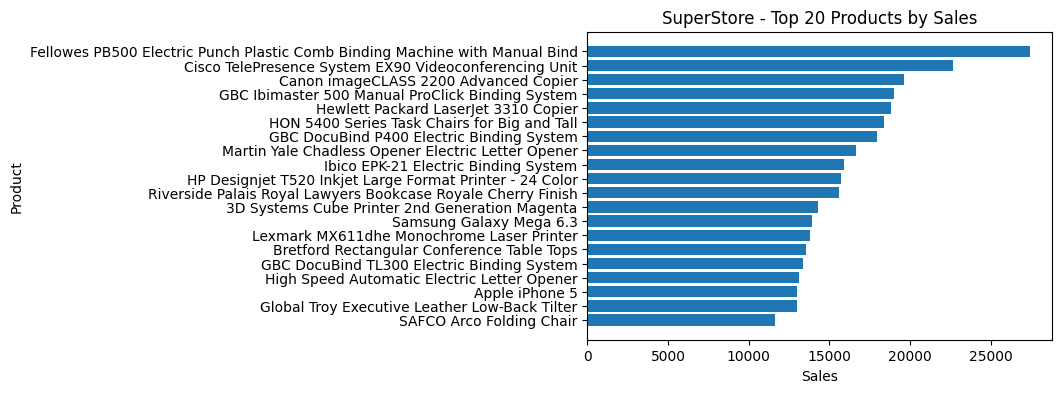

In [245]:
# Hagamos un top 20 de productos por ventas
top_products = (product.head(20).sort_values("sales"))

plt.figure(figsize=(6, 4))

plt.barh(top_products["product_name"].astype(str), top_products["sales"])
plt.title("SuperStore - Top 20 Products by Sales")
plt.xlabel("Sales"), plt.ylabel("Product")
plt.tight_layout()

plt.show()

Este gráfico de barras horizontales ordena los 20 productos con mayor facturación.

El producto líder, *Fellowes PB500 Electric Punch Plastic Comb Binding Machine*, alcanzó cerca de \$27,500 en ventas. El producto número 20, *SAFCO Arco Folding Chair*, cerró la lista con aproximadamente \$12,000.

También podemos observar que la brecha entre el primer y el vigésimo producto es de poco más del 50%. Es decir, los primeros lugares no acaparan una porción desproporcionada de los ingresos, aquí existe una distribución relativamente escalonada, aunque el Top 5 concentra una porción significativa del valor.

Además, la lista está dominada por productos de alto valor unitario y baja frecuencia de compra: máquinas de encuadernación, sistemas de videoconferencia, copiadoras, impresoras, mesas de conferencia y sillas ejecutivas. No hay productos de consumo masivo o bajo costo unitario.

Este gráfico muestra que la estrategia de ingresos de SuperStore depende de ventas esporádicas de equipos costosos. Esto genera una alta volatilidad en el flujo de caja (como se evidenció en el análisis mensual), ya que un solo pedido de estos productos puede distorsionar las ventas de un mes entero.

Como el Top 20 de ventas incluye productos que pertenecen a las 5 subcategorías destructoras de valor identificadas previamente (Tables, Bookcases, Machines, Binders, Supplies). Esto significa que el negocio está invirtiendo su capital y esfuerzo comercial en vender productos que, en su mayoría, no están generando un retorno proporcional al riesgo operativo.

In [246]:
# Ahora, veamos si los productos que generan más ventas también generan más ganancias.
top_profit_products = (product.sort_values("profit", ascending=False).head(20))

display(top_profit_products[["product_name", "category", "sub_category","sales", "profit", "profit_margin_percentage"]])

,product_name,category,sub_category,sales,profit,profit_margin_percentage
1640,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,"19,599.94","25,199.93",128.57
787,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,"27,453.38","7,753.04",28.24
1630,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,"18,839.69","6,983.88",37.07
1637,Canon PC1060 Personal Laser Copier,Technology,Copiers,"11,619.83","4,570.93",39.34
1693,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,"7,699.89","3,772.95",49.00
1541,Plantronics Savi W720 Multi-Device Wireless He...,Technology,Accessories,"9,367.29","3,324.97",35.50
448,Honeywell Enviracaire Portable HEPA Air Cleane...,Office Supplies,Appliances,"11,304.44","3,247.02",28.72
1634,Hewlett Packard 610 Color Digital Copier / Pri...,Technology,Copiers,"8,899.82","3,124.94",35.11
1572,Plantronics CS510 - Over-the-Head monaural Wir...,Technology,Accessories,"10,162.46","3,085.03",30.36
1629,Canon Imageclass D680 Copier / Fax,Technology,Copiers,"8,959.87","2,799.96",31.25


La tabla ordena los 20 productos con mayor beneficio absoluto. A diferencia de la clasificación por ventas, este ranking está dominado por productos de Technology y Office Supplies, con una presencia casi nula de Furniture y una alta concentración en la subcategoría de Copiers.


Notese que el producto **Canon imageCLASS 2200 Advanced Copier** es el producto más rentable del negocio por un margen considerable. Con \$19,599.94 en ventas, genera **\$25,199.93** de beneficio, lo que arroja un margen de 128.57%.

El segundo producto más rentable es el **Fellowes PB500** con **\$7,753.04** de beneficio.

Existe una diferencia de más de **\$17,400** entre el primer y segundo lugar. Esto indica que el beneficio del negocio depende, en gran medida, de la venta de este modelo específico de copiadora.

Además, la subcategoría **copiers** es el motor indiscutible de la empresa. Sus productos ocupan el primer, tercer y cuarto puesto, además de tener siete entradas entre el Top 20 de beneficio. Además del *Canon 2200*, aparecen el *Hewlett Packard LaserJet 3310* (\$6,983.88; 37.07%), el *Canon PC1060* (\$4,570.93; 39.34%), el *Canon PC940* (\$2,092.45; 83.04%) y el *Sharp AL-1530CS* (\$2,064.96; 32.27%).

La presencia de **Office Supplies** también es importante. Productos como el *Ativa V4110MDD Micro-Cut Shredder* (\$3,772.95; 49.00%) y la *Ibico Ibimaster 300* (\$2,318.34; 29.03%) demuestran que la maquinaria de oficina, aunque no sea el producto más vendido, también es altamente rentable.

Se destaca que ningún producto de la categoría **Furniture** aparece en el Top 20 por beneficio. Esto es consistente con el margen negativo general de la categoría y las pérdidas específicas de Tables y Bookcases.

También, notese que el análisis por beneficio revela productos que no aparecían en el Top 20 por ventas, pero que son extremadamente eficientes, estos incluyen:

- **Canon PC940 Copier:** Solo \$2,519.94 en ventas, pero **\$2,092.45** de beneficio (Margen: 83.04%).

- **Ativa V4110MDD Shredder:** \$7,699.89 en ventas, **\$3,772.95** de beneficio (Margen: 49.00%).

- **Razer Tiamat Over Ear 7.1:** \$5,119.74 en ventas, **\$2,155.89** de beneficio (Margen: 42.11%).

- **Logitech Z-906 Speaker:** \$5,609.83 en ventas, **\$2,243.93** de beneficio (Margen: 40.00%).

Estos productos son la mejor muestra de que el beneficio no requiere necesariamente de un alto volumen de ventas. Un margen alto sobre un volumen moderado puede generar más valor que un producto de alto volumen con margen bajo o negativo.

Notese también que el **Cisco TelePresence System EX90**, que era el segundo producto con mayores ventas (\$22,638.48), **no aparece en el Top 20 por beneficio** (de hecho, tiene una pérdida de -\$1,811.08).

También, el **Fellowes PB500** se mantiene en el Top 2 de ambas listas (Ventas: #1; Beneficio: #2), lo que lo convierte en el producto más equilibrado y confiable del catálogo en términos de volumen y rentabilidad simultáneos.

In [247]:
# Encontremos los productos que producen más pérdidas
loss_products = (product[product["profit"] < 0].sort_values("profit"))

display(loss_products[["product_name", "category","sub_category", "sales", "profit", "profit_margin_percentage"]].head(20))

,product_name,category,sub_category,sales,profit,profit_margin_percentage
692,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,"15,875.92","-20,978.89",-132.14
18,DMI Eclipse Executive Suite Bookcases,Furniture,Bookcases,"11,046.61","-9,904.37",-89.66
1645,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,"11,099.96","-8,879.97",-80.00
1410,Letter Size Cart,Office Supplies,Storage,"4,600.09","-7,994.45",-173.79
1687,Panasonic KX MC6040 Color Laser Multifunction ...,Technology,Machines,"1,619.82","-7,136.21",-440.56
1802,Motorola Moto X,Technology,Phones,"1,631.95","-6,776.00",-415.21
842,Ibico Hi-Tech Manual Binding System,Office Supplies,Binders,"4,300.36","-6,557.29",-152.48
132,Global Manager's Adjustable Task Chair Storm,Furniture,Chairs,"2,959.21","-5,097.08",-172.24
1650,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,"13,769.92","-4,589.97",-33.33
150,Deflect-o DuraMat Antistatic Studded Beveled M...,Furniture,Furnishings,"1,685.44","-4,171.46",-247.50


La tabla resultante muestra los 20 productos que generan las mayores pérdidas netas para el negocio.


Los tres primeros productos concentran una pérdida agregada superior a los \$39,700, estos son:

- **Ibico EPK-21 Electric Binding System:** -\$20,978.89.

- **DMI Eclipse Executive Suite Bookcases:** -\$9,904.37.

- **Cubify CubeX 3D Printer Double Head Print:** -\$8,879.97.

Un solo producto (*Ibico EPK-21*) pierde más de \$20,000, que equivale al 14% del beneficio neto total de la empresa. Esto indica una alta concentración del riesgo financiero en unos pocos SKUs.

El margen de beneficio (`profit_margin_percentage`) revela que la mayoría de estos productos operan con una economía insostenible. Un margen inferior al -100% implica que el costo total (producto, envío, descuentos, devoluciones) es mayor que el precio de venta.

Revisemos los casos extremos:

- **Panasonic KX MC6040:* -440.56% de margen (con solo \$1,619.82 en ventas, pero **-\$7,136.21** de pérdida).

- **Motorola Moto X:** -415.21% (Ventas: \$1,631.95; Pérdida: **-\$6,776.00**).

- **Letter Size Cart:** -173.79% (Ventas: \$4,600.09; Pérdida: **-\$7,994.45**).

- **Global Manager's Adjustable Task Chair:** -172.24%.

- **Deflect-o DuraMat:** -247.50%.

Estos márgenes indican que estos productos están siendo vendidos muy por debajo de su costo total, o que existe un error grave en el registro de costos asociados.


Las pérdidas no están aisladas en una sola categoría. El Top 20 afecta a las tres categorías principales:

- **Office Supplies:** Dominado por la subcategoría **Binders** (Ibico EPK-21, Ibico Hi-Tech, Fellowes PB300) y **Storage** (Letter Size Cart). Y explica por qué la subcategoría de Binders tenía un margen negativo (-3.09%).

- **Technology:** Alta concentración en **Machines** (Cubify, Panasonic, Lexmark, HP Copier) y **Phones** (Motorola Moto X, GE 30524EE4).

- **Furniture:** Las pérdidas se concentran en las subcategorías ya identificadas como críticas (**Bookcases**: DMI Eclipse; **Tables**: Hon, Bretford, Chromcraft, Bush) y **Furnishings** (Deflect-o, Tenex).


Algunos de estos productos no son de baja rotación; tienen un alto volumen de ventas:

- **Ibico EPK-21:** $15,875.92 en ventas.

- **Lexmark MX611dhe:** $13,769.92 en ventas.

- **Bretford Rectangular Conference Table Tops:** $13,565.57 en ventas.

- **DMI Eclipse Bookcases:** $11,046.61 en ventas.

- **Cubify CubeX 3D Printer:** $11,099.96 en ventas.

### **Análisis de Clientes**

Tras evaluar el desempeño del catálogo, el análisis cambiará de enfoque hacia la dimensión del cliente. Este apartado tiene como objetivo identificar y segmentar a los clientes en función de su contribución al negocio, evaluando métricas como el volumen de ventas, la frecuencia de compra (`orders`), el valor medio del pedido (`average_order_value`) y el margen de beneficio (`profit_margin_percentage`).

Es fundamental precisar que este análisis mide el Valor Observado Histórico durante el periodo de cuatro años, y no un Customer Lifetime Value (CLV) predictivo. La relevancia de este desglose radica en detectar clientes de alto valor, así como aislar perfiles de clientes que, a pesar de generar altos ingresos, están destruyendo la rentabilidad de la empresa.

In [248]:
# Generemos la tabla con los datos de los clientes

customer = (sales_detail.groupby(["customer_id", "customer_name", "segment"]).agg(
        orders=("order_key", "nunique"),
        sales=("sales", "sum"),
        quantity=("quantity", "sum"),
        profit=("profit", "sum")
        ).reset_index())

customer["average_order_value"] = (customer["sales"] / customer["orders"])
customer["profit_margin_percentage"] = np.where( customer["sales"] != 0, customer["profit"] / customer["sales"] * 100, np.nan)
customer = customer.sort_values("sales",ascending=False)

display(customer.head(20))

,customer_id,customer_name,segment,orders,sales,quantity,profit,average_order_value,profit_margin_percentage
707,SM-20320,Sean Miller,Home Office,5,"25,033.09",50.00,"-1,996.03","5,006.62",-7.97
737,TA-21385,Tom Ashbrook,Home Office,4,"14,595.62",36.00,"4,703.79","3,648.91",32.23
6,AB-10105,Adrian Barton,Consumer,10,"14,455.39",73.00,"5,543.19","1,445.54",38.35
439,KL-16645,Ken Lonsdale,Consumer,12,"14,167.82",421.00,730.10,"1,180.65",5.15
676,SC-20095,Sanjit Chand,Consumer,9,"14,142.33",87.00,"5,757.41","1,571.37",40.71
690,SE-20110,Sanjit Engle,Consumer,11,"12,209.44",76.00,-149.31,"1,109.95",-1.22
132,CC-12370,Christopher Conant,Consumer,5,"12,129.07",34.00,"2,177.05","2,425.81",17.95
771,TS-21370,Todd Sumrall,Corporate,6,"11,891.75",53.00,"2,134.49","1,981.96",17.95
91,BM-11140,Becky Martin,Consumer,4,"11,789.63",64.00,"-1,659.96","2,947.41",-14.08
727,SV-20365,Seth Vernon,Consumer,10,"11,470.95",109.00,"1,390.28","1,147.10",12.12


La tabla ordena los 20 clientes con mayor volumen de facturación (`sales`).

El cliente SM-20320 (*Sean Miller, Home Office*) se posiciona como el mayor generador de ingresos con **\$25,033.09** en ventas. Este monto es un 71% superior al segundo cliente en la lista (*Tom Ashbrook* con \$14,595.62). Un solo cliente representa una porción significativa del ingreso total del negocio.

El Top 20 muestra una alta variabilidad en la cantidad de pedidos (`orders`), oscilando entre 3 y 12 pedidos. *Ken Lonsdale* es el cliente con mayor frecuencia en esta lista con 12 pedidos, pero su volumen de ventas (\$14,167.82) apenas supera a clientes con menos de la mitad de pedidos, como *Adrian Barton* (10 pedidos, \$14,455.39).

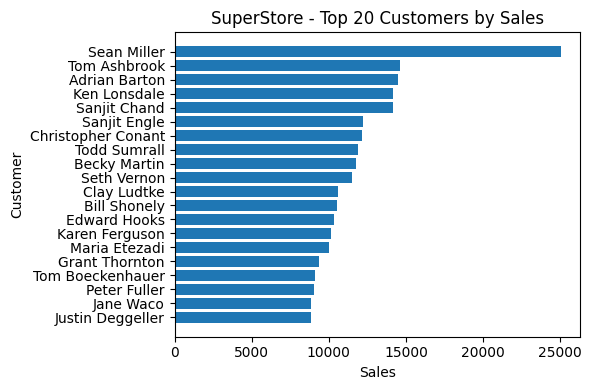

In [249]:
# Hagamos un top de clientes por ventas
top_customers = (customer.head(20).sort_values("sales"))

plt.figure(figsize=(6, 4))

plt.barh(top_customers["customer_name"], top_customers["sales"])
plt.title("SuperStore - Top 20 Customers by Sales")
plt.xlabel("Sales"), plt.ylabel("Customer")
plt.tight_layout()

plt.show()

El gráfico de barras horizontales ordena a los 20 clientes con mayor facturación.

El cliente *Sean Miller* (SM-20320) se posiciona como un outlier extremo en el gráfico, superando los \$25,000 en ventas.

Luego, existe una caída abrupta desde el primer puesto hacia el segundo *Tom Ashbrook* con $∼$\$14,500). La diferencia entre ambos es de aproximadamente **\$10,500**, lo que significa que Sean Miller genera un 71% más de ingresos que el segundo cliente de la lista.

Del segundo al vigésimo puesto, el gráfico muestra un grupo relativamente compacto que oscila entre los **\$8,800** (Justin Deggeller) y los **\$14,600** (Tom Ashbrook). No hay diferencias visualmente significativas entre estos 19 clientes.

Nuevamente, repitiendo lo que se ha escrito a lo largo de este análisis, el gráfico, al mostrar solo ventas, no revela la calidad financiera de estos clientes.

Por ejemplo, *Sean Miller* (SM-20320), a pesar de liderar las ventas, opera con una pérdida de **-\$1,996.03** (margen: -7.97%).

En este grupo también aparecen *Grant Thornton* (GT-14635) con -\$4,108.66 (margen -44.02%) y *Peter Fuller* (PF-19120) con -\$10,572.37 (margen -116.66%).

También, hay un posible riesgo, la empresa depende en gran medida de un solo cliente (sea Sean Miller) para generar ingresos. Si este cliente dejara de comprar, las ventas caerían drásticamente, sin embargo, dado que este cliente genera pérdidas, su retención no debería ser una prioridad estratégica bajo la estructura actual.

In [250]:
# Ahora, encontremos a los clientes que tengan buenas ventas, pero también una buena ganancia

customer["sales_rank"] = (customer["sales"].rank(ascending=False, method="min"))
customer["profit_rank"] = (customer["profit"].rank(ascending=False, method="min"))
customer["rank_gap"] = (customer["profit_rank"] - customer["sales_rank"])

display(customer.sort_values("rank_gap", ascending=False).head(20))

,customer_id,customer_name,segment,orders,sales,quantity,profit,average_order_value,profit_margin_percentage,sales_rank,profit_rank,rank_gap
595,PF-19120,Peter Fuller,Consumer,4,"9,062.86",75.00,"-10,572.37","2,265.72",-116.66,18.00,799.00,781.00
311,GT-14635,Grant Thornton,Corporate,3,"9,334.07",24.00,"-4,108.66","3,111.36",-44.02,16.00,792.00,776.00
707,SM-20320,Sean Miller,Home Office,5,"25,033.09",50.00,"-1,996.03","5,006.62",-7.97,1.00,776.00,775.00
91,BM-11140,Becky Martin,Consumer,4,"11,789.63",64.00,"-1,659.96","2,947.41",-14.08,9.00,772.00,763.00
567,NF-18385,Natalie Fritzler,Consumer,7,"8,322.83",50.00,"-1,764.97","1,188.98",-21.21,22.00,774.00,752.00
584,NW-18400,Natalie Webber,Consumer,7,"7,234.01",78.00,"-4,400.40","1,033.43",-60.83,42.00,793.00,751.00
82,BF-11170,Ben Ferrer,Home Office,13,"7,848.50",143.00,-691.18,603.73,-8.81,29.00,748.00,719.00
181,CS-12505,Cindy Stewart,Consumer,6,"5,690.05",40.00,"-6,637.95",948.34,-116.66,80.00,797.00,717.00
373,JH-15985,Joseph Holt,Consumer,6,"7,846.72",58.00,-644.70,"1,307.79",-8.22,30.00,745.00,715.00
245,Dp-13240,Dean percer,Home Office,11,"7,198.76",410.00,-862.45,654.43,-11.98,44.00,756.00,712.00


La tabla ordena a los clientes con mayor rank_gap positivo, es decir, aquellos cuya posición en beneficio es mucho peor que su posición en ventas.

Expliquemos un poco de la lógica de los Rankings_

- **sales_rank:** Ranking descendente de ventas. El cliente con más ventas tiene rango 1.

- **profit_rank:** Ranking descendente de beneficio. El cliente con más beneficio tiene rango 1.

- **rank_gap:** Si el profit_rank es 799 y el sales_rank es 18, el rank_gap es 781. Esto indica que el cliente es el puesto 18 en ventas, pero el puesto 799 en beneficio.

Revisemos los peores clientes que tiene la empresa:

- **Sean Miller** (SM-20320) tiene sales_rank 1, profit_rank 776 y rank_gap 775. Es el cliente con mayores ventas de todo el negocio, pero su beneficio es uno de los peores (ya que tiene una pérdida de **-\$1,996.03**, margen -7.97%).

- **Dennis Pardue** (DP-13390) que tiene sales_rank 101, profit_rank 800 y rank_gap 699. Presenta la peor pérdida absoluta del Top 20 (**-\$22,752.34**) con un margen de -445.69%.

- **Peter Fuller** (PF-19120) tiene sales_rank 18, profit_rank 799 y rank_gap 781. Es el segundo cliente con mayor rank_gap. Ventas de $\9,062.86, pero pérdida de **-\$10,572.37** (margen -116.66%).

- **Grant Thornton** (GT-14635) tiene sales_rank 16, profit_rank 792 y rank_gap 776. Ventas de \$9,334.07, pero una pérdida de **-\$4,108.66** (margen -44.02%).

- **Amy Cox** (AC-10450) tiene sales_rank 86, profit_rank 795 y rank_gap 709. Ventas de \$5,527.85, pero una pérdida de **-\$5,115.03** (margen -92.53%).

- **Cindy Stewart** (CS-12505) tiene sales_rank 80, profit_rank 797 y rank_gap 717. Ventas de \$5,690.05, pero una pérdida de **-\$6,637.95** (margen -116.66%).

Existe una concentración notable en el segmento *Corporate* y *Home Office* para los casos de mayor pérdida absoluta (Grant Thornton, Sean Miller, Dennis Pardue, Amy Cox). Esto sugiere que las negociaciones corporativas o los contratos de alto volumen están incluyendo descuentos o alguna otra situación que superan la capacidad de margen del negocio.

Además, los clientes con mayor average_order_value (como Sean Miller o Grant Thornton) son los que presentan los peores márgenes. Esto confirma que el problema no es la cantidad de pedidos, sino la economía unitaria de los productos que compran.

También está la parte de que no todos los clientes *tóxicos* compran poco. Cindy Stewart, Peter Fuller y Dennis Pardue tienen entre 4 y 9 pedidos, pero sus pérdidas superan los \$6,000. El problema es la estructura de precios de los productos que adquieren y no la frecuencia de compra.


Este Top 20 de clientes con mayor rank_gap acumula pérdidas que superan los **\$80,000**. Esto representa más del 54% del beneficio neto global de la empresa (\$146,888.01). Es decir, más de la mitad de las ganancias generadas por el resto de la cartera se destinan a subsidiar las compras de este grupo reducido de clientes.


## **Análisis Geográfico por Región**

El análisis geográfico permite evaluar la distribución territorial del negocio. El objetivo es cuantificar el volumen de operación (pedidos, clientes, unidades) y contrastarlo con la rentabilidad generada (beneficio y margen) en cada región. La comparación entre ingresos y beneficios es fundamental, ya que una región puede liderar en volumen de ventas y, simultáneamente, presentar una eficiencia operativa inferior a otras con menor facturación.

In [251]:
# Creamos nuestra tabla con los datos geográficos

region = (sales_detail.groupby("region").agg(
        orders=("order_key", "nunique"),
        customers=("customer_id", "nunique"),
        sales=("sales", "sum"),
        quantity=("quantity", "sum"),
        profit=("profit", "sum")).reset_index())

region["profit_margin_percentage"] = (region["profit"] / region["sales"] * 100)

region = region.sort_values("sales", ascending=False)

display(region)

,region,orders,customers,sales,quantity,profit,profit_margin_percentage
3,West,1637,686,"696,509.51","22,727.00","44,094.20",6.33
1,East,1475,681,"645,367.24","21,471.00","53,177.88",8.24
0,Central,1179,629,"448,163.87","12,931.00","28,701.42",6.40
2,South,822,512,"366,734.48","11,167.00","20,914.51",5.70


La tabla desglosa las métricas del negocio en sus cuatro regiones operativas.

- **West** es la región con mayor volumen de ventas, pedidos y clientes, sin embargo, su margen de beneficio (6.33%) es inferior al de East (8.24%), lo que indica que, a pesar de mover el mayor volumen de capital, su eficiencia operativa no es la óptima. Su alta cantidad de unidades vendidas (22,727) sugiere una predominancia de productos de bajo costo unitario o una estructura de costos que absorbe gran parte del margen.

- **East** es la región más rentable en términos absolutos y relativos. Con un 7.3% menos de ventas que West, genera un 20.6% más de beneficio. Su margen del 8.24% es el más alto del negocio. Esto indica una mejor gestión de precios, un mix de productos más rentable o una estructura de costos operativos más eficiente. En otras palabras, es el motor geográfico-financiero de la empresa.

- **Central** ocupa el tercer lugar en todas las métricas. Su margen (6.40%) es muy similar al de West (6.33%), pero su volumen de ventas es un 35.6% inferior. Representa una operación estable pero sin el dinamismo de las regiones costeras.

- **South** es la región con el menor desempeño en todas las métricas- Tiene menos pedidos, menos clientes, menores ventas, menor beneficio y el margen más bajo (5.70%). Su baja cantidad de unidades vendidas (11,167) y su reducido margen indican un problema estructural de volumen y rentabilidad en esta zona.

Esto indica una dependencia de la empresa con las regiones costeras (West y East) ya que concentran más del 62% del beneficio total del negocio (**\$44,094** + **\$53,177** = **\$97,271** de **\$146,888**).

El hecho de que West lidere en ventas, pero tenga un margen inferior a East demuestra que el negocio no está gestionando el volumen de manera uniforme. El crecimiento en West no se traduce en rentabilidad proporcional.

Además, la región East demuestra que un menor volumen de ventas puede generar un mayor beneficio si se gestiona con un margen superior. La diferencia de margen entre East (8.24%) y South (5.70%) es de 2.54 puntos porcentuales, lo que, aplicado al volumen de South, generaría un beneficio adicional significativo.

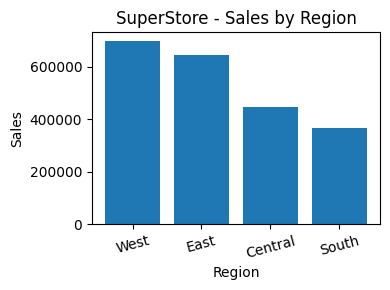

In [252]:
# Realizamos el gráfico de ventas por región para facilitar la comparación del tamaño de ventas entre regiones

plt.figure(figsize=(4, 3))

plt.bar(region["region"], region["sales"])
plt.title("SuperStore - Sales by Region")
plt.xlabel("Region"), plt.ylabel("Sales")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

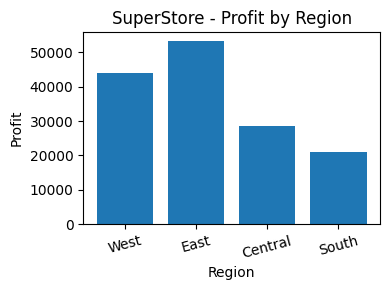

In [253]:
# Grafiquemos también las ganancias por región para denotar los mayores contribuyentes
plt.figure(figsize=(4, 3))

plt.bar(region["region"], region["profit"])
plt.title("SuperStore - Profit by Region")
plt.xlabel("Region"), plt.ylabel("Profit")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

En resumen, la estructura geográfica del negocio está desequilibrada. El análisis de las métricas revela que el crecimiento en ventas de West no está acompañado de una eficiencia proporcional, mientras que Central y South presentan márgenes por debajo del promedio global (6.8%). La relevancia de este desglose radica en que el beneficio neto de la empresa no depende únicamente de mantener el volumen de West, sino de entender por qué East genera más valor con menos ingresos y por qué Central y South operan con una rentabilidad tan ajustada.

### **Análisis por País**

El análisis geográfico desciende al nivel de país para identificar la concentración de los mercados y evaluar la eficiencia operativa en cada uno. El objetivo es cuantificar el volumen de facturación (sales), la base de clientes (customers) y la rentabilidad neta (profit y profit_margin_percentage) para diferenciar entre mercados de alto volumen con margen bajo y mercados de bajo volumen con alta eficiencia. Esta comparación permite dimensionar la dependencia del negocio hacia un solo territorio y su impacto en la rentabilidad global.

In [254]:
# Obtengamos la tabla con los datos de cada país
country = (sales_detail.groupby("country").agg(
        orders=("order_key", "nunique"),
        customers=("customer_id", "nunique"),
        sales=("sales", "sum"),
        profit=("profit","sum")
        ).reset_index()
)

country["profit_margin_percentage"] = (country["profit"] / country["sales"] * 100)
country = country.sort_values("sales", ascending=False)

display(country)

,country,orders,customers,sales,profit,profit_margin_percentage
1,United States,5009,793,"2,129,823.78","143,851.66",6.75
0,Canada,104,33,"26,951.32","3,036.35",11.27


La tabla desglosa el desempeño del negocio en sus dos mercados operativos: Estados Unidos y Canadá. Los datos evidencian una dependencia casi absoluta de un solo país (EE.UU.).

- **Estados Unidos** es el mercado dominante. Representa aproximadamente el 98.7% de las ventas totales del negocio y el 97.9% del beneficio global. Su volumen de pedidos y clientes es significativamente superior al de Canadá. Sin embargo, su margen del 6.75% está muy cerca del promedio global (6.81%), lo que indica que la rentabilidad de la empresa está determinada casi en su totalidad por la eficiencia de este único mercado. Cualquier variación en su margen tiene un impacto directo y multiplicador en el resultado global.

- **Canadá**, en cambio, es un mercado residual en términos de volumen (1.3% de las ventas totales), quizá por eso mismo es significativamente más eficiente que Estados Unidos. Su margen del 11.27% supera en 4.52 puntos porcentuales al de EE.UU. Esta diferencia indica que, aunque el volumen es pequeño, la economía unitaria de los productos vendidos en Canadá o su estructura de costos operativos es más favorable.

La estructura de ingresos está concentrada en un solo país. La empresa no tiene una diversificación geográfica real, sino que su supervivencia financiera depende de mantener el volumen, margen y presencia en Estados Unidos.

### **Análisis por Estado / Provincia**

Dado que la operación comercial se concentra casi en su totalidad en dos países, el siguiente nivel de granularidad geográfica consiste en desglosar el desempeño a nivel de estado o provincia. El objetivo de esta sección es identificar los mercados regionales específicos que impulsan el volumen de facturación, así como detectar discrepancias en la rentabilidad. Este análisis permite evaluar si los estados con mayor volumen de ventas son también los más rentables, o si, por el contrario, existen ineficiencias operativas o de precios que afectan el margen final en determinadas regiones.

In [255]:
# Hagamos la tabla con los datos de cada estado o provincia de los países en los que opera la empresa.
state = (sales_detail.groupby("state").agg(
        orders=("order_key","nunique"),
        customers=("customer_id", "nunique"),
        sales=("sales", "sum"),
        profit=("profit", "sum")
        ).reset_index()
)

state["profit_margin_percentage"] = (state["profit"] / state["sales"] *100)
state = state.sort_values("sales", ascending=False)

display(state.head(20))


,state,orders,customers,sales,profit,profit_margin_percentage
5,California,1021,577,"439,432.79","48,439.88",11.02
34,New York,562,415,"287,174.80","46,568.70",16.22
51,Texas,487,370,"152,465.80","-25,695.06",-16.85
55,Washington,256,224,"117,037.43","24,046.28",20.55
43,Pennsylvania,288,257,"112,409.92","-14,716.79",-13.09
10,Florida,200,181,"84,853.87","-5,281.27",-6.22
13,Illinois,276,237,"76,125.53","-15,052.30",-19.77
39,Ohio,236,202,"75,695.54","-16,952.44",-22.40
23,Michigan,117,106,"67,593.41","21,923.13",32.43
54,Virginia,115,107,"64,385.46","14,655.81",22.76


El análisis de los 20 estados con mayor volumen de ventas revela una profunda desconexión entre la generación de ingresos y la rentabilidad. La empresa tiene un problema estructural muy marcado y es que varios de sus mercados más grandes están operando con márgenes negativos, lo que está drenando el beneficio global.

Primero, notese el caso de **California**. Lidera indiscutiblemente con **\$439,432** en ventas y un margen saludable del **11.02%**. Le sigue **Nueva York** con **\$287,174** en ventas y un margen aún mejor (**16.22%**). Estos dos estados representan el núcleo del negocio y son los principales contribuyentes al beneficio. Sin embargo, el tercer estado con mayor volumen, **Texas** (\$152,465), presenta un margen negativo del -16.85%, lo que indica que por cada dólar vendido, la empresa pierde dinero en ese mercado.

Es decir, una parte significativa del volumen de ventas en EE.UU. se está realizando a pérdida. Estados con ventas considerables como **Pennsylvania** (-13.09%), **Illinois** (-19.77%), **Ohio** (-22.40%), **Florida** (-6.22%) y, especialmente, **North Carolina** (-41.92%) destruyen valor. Mientras que las ganancias de estados como California y Nueva York están subsidiando las pérdidas de estos mercados clave.

En contraste, existen estados con un volumen de ventas moderado pero una eficiencia operativa sobresaliente. Por ejemplo, **Indiana** (41.80%), **Minnesota** (35.44%), **Georgia** (34.92%) y **Michigan** (32.43%) demuestran que es posible operar con márgenes muy superiores al promedio global (6.81%). Estos mercados probablemente tengan una estructura de costos más ligera, una mezcla de productos más rentable o menores niveles de descuento.

### **Análisis por Ciudad**

El análisis a nivel de ciudad representa el nivel más granular de nuestro estudio geográfico. Su objetivo es identificar los núcleos urbanos que concentran la mayor parte del volumen de facturación y evaluar la eficiencia operativa en cada uno de ellos.

In [256]:
# Obtengamos la tabla con los datos de ciudad
city = (sales_detail.groupby(["city", "state", "region"]).agg(
        orders=("order_key", "nunique"),
        customers=("customer_id", "nunique"),
        sales=("sales", "sum"),
        profit=("profit","sum")
        ).reset_index()
)

city["profit_margin_percentage"] = (city["profit"] / city["sales"] * 100)
city = city.sort_values("sales", ascending=False)

display(city.head(20))

,city,state,region,orders,customers,sales,profit,profit_margin_percentage
386,New York City,New York,East,450,355,"235,605.36","36,280.34",15.40
316,Los Angeles,California,West,384,304,"168,747.27","20,149.31",11.94
511,San Francisco,California,West,265,232,"106,950.24","12,745.54",11.92
436,Philadelphia,Pennsylvania,East,265,239,"104,975.02","-13,019.68",-12.40
525,Seattle,Washington,West,212,188,"98,007.88","19,820.26",20.22
243,Houston,Texas,Central,188,172,"58,031.52","-9,894.60",-17.05
92,Chicago,Illinois,Central,171,155,"46,065.32","-9,254.91",-20.09
510,San Diego,California,West,67,67,"40,322.28","4,972.81",12.33
255,Jacksonville,Florida,South,38,38,"37,991.28","-2,504.67",-6.59
145,Detroit,Michigan,Central,53,50,"34,209.85","10,817.35",31.62


El desglose de las 20 ciudades con mayor volumen de ventas confirma y profundiza los hallazgos del análisis estatal. La facturación está fuertemente concentrada en unas pocas metrópolis, pero la rentabilidad es desigual en toda su extensión.

- **Nueva York** lidera con \$235,605 en ventas y un margen del 15.40%, consolidándose como el mercado más importante y rentable. Le siguen Los Ángeles (\$168,747) y San Francisco (\$106,950) con márgenes cercanos al 12%, y Seattle (\$98,007) que destaca con un margen del 20.22%. Estas cuatro ciudades de las costas Este (East) y Oeste (West) representan el núcleo financiero de la empresa y demuestran que es posible mantener altos volúmenes de venta con una buena eficiencia.

Pero varias de las ciudades más grandes de la región Central y algunas del Este están operando con pérdida. **Filadelfia** (\$104,975 en ventas, -12.40% de margen), **Houston** (\$58,031, -17.05%), **Chicago** (\$46,065, -20.09%), **San Antonio** (\$21,633, -34.37%) y **Dallas** (\$18,564, -15.00%) presentan márgenes negativos severos. Esto significa que, a mayor volumen de ventas en estas ciudades, mayor es la pérdida para la empresa.

En contraste, existen ciudades con un volumen de ventas moderado que muestran una eficiencia operativa sobresaliente. **Atlanta** (40.78%), **Minneapolis** (39.78%), **Jackson** (35.83%), **Providence** (34.00%) y **Detroit** (31.62%) demuestran que la economía unitaria en estas zonas es mucho más favorable.

Esta concentración geográfica a nivel de ciudad revela una dependencia crítica de Nueva York y California para sostener las finanzas de la empresa. Al mismo tiempo, expone una crisis de rentabilidad en las principales ciudades de Texas, Illinois y Pennsylvania. Es imperativo realizar una auditoría operativa urgente en estas ciudades con márgenes negativos para identificar las causas raíz (ya sean descuentos excesivos, altos costos de envío o devoluciones) y corregirlas. De lo contrario, el crecimiento en volumen seguirá erosionando el beneficio global.

## **Análisis Lógistico**

Habiendo explorado la dimensión geográfica del negocio, cambiamos el enfoque hacia la dimensión operativa y logística. Para ello, utilizamos la vista `order_summary`, la cual está diseñada explícitamente para métricas a nivel de pedido y contiene un total de 5,113 pedidos. Este cambio de granularidad es fundamental, ya que las métricas logísticas principales (como los días de envío y el modo de transporte) no se comportan a nivel de línea de producto, sino que son atributos intrínsecos a la orden completa. El objetivo de esta sección es analizar la eficiencia de la cadena de suministro, los tiempos de entrega y cómo estos factores operativos influyen en la rentabilidad final.

Antes de proceder con el análisis visual, se realizó un proceso de preparación y control de calidad de los datos logísticos. Este paso previo revela hallazgos importantes sobre la integridad de la información y el estado actual de las operaciones.



In [257]:
logistics = order_summary.copy()


# Si Ship Mode está ausente, lo representamos como Unknown para que esos pedidos no desaparezcan del análisis.
logistics["ship_mode"] = (logistics["ship_mode"].fillna("Unknown"))

# Convertimos Shipping Days en variable numérica.
logistics["shipping_days"] = pd.to_numeric(logistics["shipping_days"], errors="coerce")

display(logistics.head())

,order_key,order_id,order_date,order_year,order_month,order_year_month,ship_date,shipping_days,ship_mode,customer_id,customer_name,segment,country,state,city,postal_code,region,total_order_lines,distinct_products,total_sales,total_quantity,average_line_discount,total_profit,unknown_sales_lines,unknown_quantity_lines,unknown_profit_lines
0,1,CA-2023-100867,2023-10-19,2023,10,2023-10,2023-10-24,5,Standard Class,EH-14125,Eugene Hildebrand,Home Office,Canada,British Columbia,Vancouver,V6G,West,1,1,32.70,3.00,0.00,8.50,0,0,0
1,2,CA-2023-107153,2023-09-28,2023,9,2023-09,2023-10-03,5,Standard Class,GZ-14545,George Zrebassa,Corporate,Canada,Quebec,Montreal,H1A,East,1,1,10.69,2.00,0.20,3.74,0,0,0
2,3,CA-2023-115238,2023-01-21,2023,1,2023-01,2023-01-24,3,Standard Class,JW-15220,Jane Waco,Corporate,Canada,Ontario,Toronto,M7A,East,5,5,281.16,22.00,0.00,89.20,0,0,0
3,4,CA-2023-115777,2023-08-19,2023,8,2023-08,2023-08-24,5,Standard Class,DO-13645,Doug O'Connell,Consumer,Canada,Quebec,Montreal,H1B,East,1,1,387.99,1.00,0.00,NaN,0,0,1
4,5,CA-2023-117964,2023-12-02,2023,12,2023-12,2023-12-06,4,Standard Class,MK-19560,Michael Knudson,Corporate,Canada,New Brunswick,Moncton,E1A,East,2,2,56.42,12.00,0.40,-18.54,0,0,0


### **Análisis por Ship Mode**

Una vez preparados los datos logísticos, el siguiente paso es desglosar el desempeño operativo según el modo de envío (`ship_mode`). El objetivo de esta sección es cuantificar la utilización de cada modalidad de transporte, evaluar su contribución a las ventas y al beneficio, y contrastar la velocidad de entrega con la rentabilidad que generan. Esta comparación permite identificar si los servicios más rápidos (y presumiblemente más costosos) están justificados por su volumen o si, por el contrario, están erosionando el margen operativo.

In [258]:
## Hacemos la tabla con los datos de ship_mode
ship_mode = (logistics.groupby("ship_mode").agg(
        orders=("order_key", "nunique"),
        customers=("customer_id", "nunique"),
        sales=("total_sales", "sum"),
        quantity=("total_quantity", "sum"),
        profit=("total_profit", "sum"),
        average_shipping_days=("shipping_days", "mean")
      ).reset_index()
)

ship_mode["profit_margin_percentage"] = (ship_mode["profit"] / ship_mode["sales"] * 100)
ship_mode["order_share_percentage"] = (ship_mode["orders"] / ship_mode["orders"].sum() * 100)

display(ship_mode)


,ship_mode,orders,customers,sales,quantity,profit,average_shipping_days,profit_margin_percentage,order_share_percentage
0,First Class,756,480,"313,731.12","9,347.00","24,415.21",2.19,7.78,14.79
1,Same Day,247,210,"122,710.82","3,920.00","2,537.06",0.04,2.07,4.83
2,Second Class,926,536,"434,381.58","14,750.00","13,323.57",3.23,3.07,18.11
3,Standard Class,2910,776,"1,230,106.62","38,260.00","98,457.52",4.99,8.00,56.91
4,Unknown,274,227,"55,844.94","2,019.00","8,154.66",3.97,14.60,5.36


El análisis de los cinco modos de envío (incluyendo los envíos de los que no se sabe su modo de envío `Unknown`) revela una clara dependencia del servicio estándar, pero también expone ineficiencias críticas en las modalidades intermedias y exprés.

- **Standard Class:** Es la modalidad dominante, concentrando el 56.91% de los pedidos y generando el mayor volumen de ventas (\$1,230,106.62) y beneficio absoluto (\$98,457.52). Su margen del 8.00% es el más alto entre los servicios conocidos. Su tiempo promedio de entrega es de 4.99 días. Este servicio es el pilar financiero y operativo de la empresa.

- **Second Class:** A pesar de ser la segunda modalidad más utilizada (18.11% de los pedidos), presenta un margen muy bajo de 3.07%, a pesar de tener un volumen de ventas considerable (\$434,381.58). Esto sugiere que los costos operativos de esta modalidad están consumiendo casi por completo el beneficio. Es un candidato claro para una auditoría de costos.

- **First Class:** Representa el 14.79% de los pedidos y mantiene un margen saludable del 7.78%, muy cercano al de Standard Class, pero con un tiempo de entrega mucho menor (2.19 días). Esto indica que la empresa ha logrado gestionar eficientemente este servicio *premium*.

- **Same Day:** Es la modalidad menos utilizada (4.83%), con el menor volumen de ventas (\$122,710.82) y el margen más bajo (2.07%). Su tiempo de entrega es prácticamente inmediato (0.04 días), lo que implica costos logísticos muy altos que apenas se cubren con el precio cobrado. Funciona más como un diferenciador de servicio al cliente que como una fuente de beneficio.

- **Unknown:** Esta anomalía aparece en pedidos a los cuales no se registró su modalidad de envío. Representa el 5.36% de los pedidos, presenta el margen más alto de toda la tabla (14.60%). Es fundamental investigar su origen para corregir la integridad de los datos y entender si este alto margen es real o un artefacto del sistema.

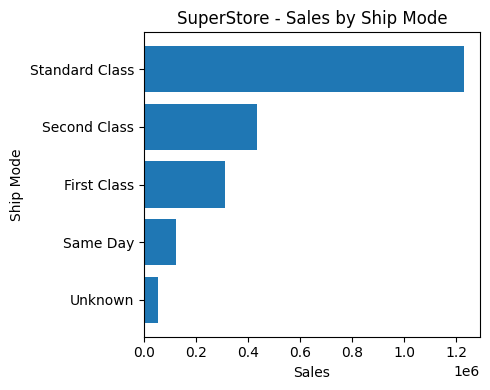

In [259]:
# Veamos cuáles son las ventas por ship mode para visualizar cuánto negocio se mueve mediante cada modalidad.

ship_mode_plot = (ship_mode.sort_values("sales", ascending=True))

plt.figure(figsize=(5, 4))

plt.barh(ship_mode_plot["ship_mode"], ship_mode_plot["sales"])
plt.title("SuperStore - Sales by Ship Mode")
plt.xlabel("Sales"), plt.ylabel("Ship Mode")
plt.tight_layout()

plt.show()

El gráfico confirma visualmente que hay una dependencia casi total de una sola modalidad de envío.

La barra que representa al Standard Class se extiende muy por encima de las demás, superando el umbral de 1.2 millones en ventas. Esto no solo confirma que es el modo más utilizado, sino que visualmente evidencia que es el pilar financiero de la empresa. La facturación de la compañía está intrínsecamente ligada a esta modalidad.

Además, se observa una caída escalonada muy pronunciada. Del **Standard Class** se pasa abruptamente al **Second Class** (poco más de 0.4 millones), seguido por el **First Class** (unos 0.3 millones). La brecha visual entre la primera y la segunda barra es enorme, lo que subraya que los modos exprés o intermedios son una fracción del negocio en términos de ingresos.

En la parte inferior del gráfico, **Same Day** y **Unknown** apenas tienen representación visual en comparación con el líder.


In [260]:
# También veamos cómo se distribuyen los promedios de entregas

def clasificar_tiempo_envio(dias):
    """
    Convierte Shipping Days en categorías interpretables.
    """
    if pd.isna(dias):
        return "Unknown"
    elif dias == 0:
        return "Same Day"
    elif 1 <= dias <= 2:
        return "1-2 Days"
    elif 3 <= dias <= 4:
        return "3-4 Days"
    elif 5 <= dias <= 7:
        return "5-7 Days"
    else:
        return "8+ Days"

In [261]:
logistics["shipping_time_group"] = (logistics["shipping_days"].apply(clasificar_tiempo_envio))

shipping_groups = (logistics.groupby("shipping_time_group").agg(
        orders=("order_key", "nunique"),
        sales=("total_sales","sum"),
        profit=("total_profit", "sum"),
        average_shipping_days=("shipping_days", "mean")
        ).reset_index()
)

shipping_groups["order_share_percentage"] = (shipping_groups["orders"] / shipping_groups["orders"].sum() * 100)

display(shipping_groups)

,shipping_time_group,orders,sales,profit,average_shipping_days,order_share_percentage
0,1-2 Days,874,"403,018.79","39,952.96",1.79,17.09
1,3-4 Days,1950,"793,232.68","53,204.12",3.74,38.14
2,5-7 Days,2034,"838,082.19","50,735.04",5.60,39.78
3,8+ Days,1,198.24,70.83,11.00,0.02
4,Same Day,254,"122,243.19","2,925.07",0.00,4.97


Notese que la mayoría de los pedidos se mueven en rangos de 3 a 7 días.

Las categorías de 3-4 días (38.14% de los pedidos) y 5-7 días (39.78% de los pedidos) concentran casi el 78% de los pedidos totales y el grueso de las ventas (más de \$1.6 millones en conjunto). Sin embargo, sus márgenes de beneficio son moderados. Tenemos 6.71% para 3-4 días y 6.05% para 5-7 días. Esto indica que el volumen principal del negocio se mueve en plazos estándar, con una rentabilidad que, aunque positiva, está por debajo de lo que se podría obtener con envíos más rápidos.

Además, notese que las categorías entre 1-2 días representan el 17.09% de los pedidos, lo cual es la más eficiente de todas. Genera \$403,018.79 en ventas con un beneficio de **\$39,952.96**, lo que arroja un margen estimado del 9.91%, el más alto entre los grupos significativos. Esto demuestra que los clientes que reciben sus pedidos en 1-2 días no solo están dispuestos a pagar más, sino que la estructura de costos para cumplir con esa promesa es bastante eficiente.

A pesar de que el envío **Same Day** tiene un tiempo de entrega de 0 días, su margen es el más bajo de todos (2.39%). Esto confirma lo que vimos en el análisis por ship_mode sobre que la conveniencia extrema tiene un costo logístico muy alto que casi consume todo el beneficio. Aunque se puede justificar indicando que se utiliza como un diferenciador de servicio y no como una fuente de valor.

Ahora, existe un único pedido que tardó 11 días en entregarse, generando \$198.24 en ventas y **\$70.83** en beneficio (35.73% de margen). Al ser un caso aislado, no representa una tendencia, pero sí evidencia una posible falla en el sistema de seguimiento o una entrega excepcionalmente problemática que debe ser monitoreada para evitar que se convierta en un patrón.

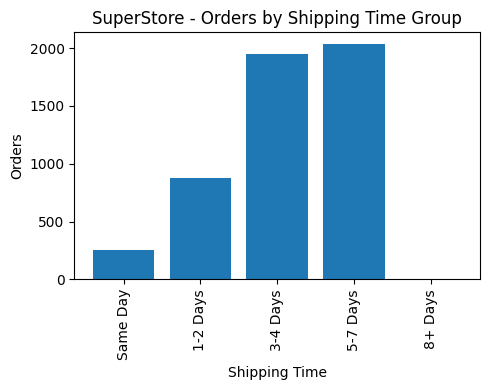

In [262]:
# Convirtirtamos la distribución de tiempos de entrega en una comparación visual sencilla
orden_grupos = [
    "Same Day",
    "1-2 Days",
    "3-4 Days",
    "5-7 Days",
    "8+ Days",
    "Unknown"
]

shipping_groups["sort_order"] = (shipping_groups["shipping_time_group"]
    .map({
        grupo: indice
        for indice, grupo
        in enumerate(orden_grupos)
    })
)

shipping_groups = (shipping_groups.sort_values("sort_order"))

plt.figure(figsize=(5, 4))

plt.bar(shipping_groups["shipping_time_group"],shipping_groups["orders"])
plt.title("SuperStore - Orders by Shipping Time Group")
plt.xlabel("Shipping Time"), plt.ylabel("Orders")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()


El gráfico revela una distribución con una marcada forma de campana, donde la gran mayoría de los pedidos se concentran en los rangos intermedios de tiempo de entrega.

Las barras correspondientes a 3-4 Days y 5-7 Days son, con diferencia, las más altas del gráfico, superando ambas los 1,900 pedidos y rozando los 2,000. Visualmente, esto evidencia que casi el 80% del volumen operativo de la empresa se gestiona en estos dos rangos.

Además, se observa un fuerte descenso tanto hacia la izquierda (envíos más rápidos) como hacia la derecha (envíos más lentos).

A la izquierda, el grupo 1-2 Days tiene una representación significativa (cerca de 875 pedidos), pero muy inferior a los grupos centrales.

El grupo Same Day es claramente una minoría, con apenas 250 pedidos, confirmando que es un servicio de nicho.

A la derecha, la barra de 8+ Days es prácticamente imperceptible en el gráfico, lo que confirma que las entregas extremadamente lentas son una anomalía estadística (apenas 1 pedido), no un problema generalizado, lo cual está bien, pero debe investigarse los motivos de ese retraso.

In [263]:
# Una región puede parecer más lenta simplemente porque utiliza una mayor proporción de modalidades lentas.
# Por eso cruzaremos: Region + Ship Mode para notar las diferencias persistentes dentro de la misma modalidad.

logistics_region = (logistics.groupby(["region", "ship_mode"]).agg(
        orders=("order_key", "nunique"),
        sales=("total_sales", "sum"),
        profit=("total_profit", "sum"),
        average_shipping_days=("shipping_days", "mean")
        ).reset_index()
)

logistics_region["profit_margin_percentage"] = (logistics_region["profit"] / logistics_region["sales"] * 100)
logistics_region = logistics_region.sort_values("ship_mode")

display(logistics_region)

,region,ship_mode,orders,sales,profit,average_shipping_days,profit_margin_percentage
0,Central,First Class,169,"51,502.24","3,057.52",2.23,5.94
5,East,First Class,231,"110,873.71","13,105.67",2.23,11.82
10,South,First Class,114,"44,160.39",-229.47,2.19,-0.52
15,West,First Class,242,"107,194.79","8,481.49",2.11,7.91
1,Central,Same Day,57,"18,488.00","1,462.78",0.05,7.91
6,East,Same Day,71,"41,621.47","-1,902.24",0.00,-4.57
11,South,Same Day,37,"21,066.11","-1,782.02",0.03,-8.46
16,West,Same Day,82,"41,535.24","4,758.53",0.09,11.46
2,Central,Second Class,212,"90,129.72","1,702.15",3.36,1.89
17,West,Second Class,304,"147,313.19","-5,519.64",3.16,-3.75


El análisis cruzado revela que los tiempos de entrega (`average_shipping_days`) son notablemente consistentes en todas las regiones para un mismo modo de envío (por ejemplo, Standard Class ronda los 5 días en todas partes). Por lo tanto, el problema no es la velocidad logística, sino la rentabilidad diferenciada por región. Por ejemplo:

- A nivel global, el envío **Same Day** tenía un margen bajo (2.07%). Sin embargo, al desglosarlo, vemos que en la región East el margen es del -4.57% y en la South es del -8.46%. Esto significa que la empresa está perdiendo dinero en cada envío Same Day en estas dos regiones. En contraste, en West este mismo servicio es altamente rentable (11.46%), y en Central también es positivo (7.91%).

- El envío **First Class** es generalmente rentable (entre 5% y 12% en la mayoría de las regiones), pero en la región South presenta un margen negativo del -0.52%. Esto indica que los costos operativos de priorizar envíos en el sur están superando los ingresos generados.

- A nivel global, el **Second Class** tiene un margen bajo (3.07%). En la región West, a pesar de tener un volumen considerable (\$147,313 en ventas), el margen es negativo (-3.75%). Sin embargo, en la región South, el Second Class es sorprendentemente rentable (12.23%), y en East también es aceptable (5.87%).

- **Standard Class** sigue siendo el modo más estable. En todas las regiones es rentable, con márgenes que oscilan entre el 4.93% (South) y el 8.99% (East). Esto confirma que el núcleo del negocio (envío estándar) es sólido, aunque la región Sur tiene un margen notablemente inferior al resto.

### **Correlaciones**

Hasta ahora, hemos analizado las dimensiones del negocio de forma individual (geografía, logística, categorías, etc.). El siguiente paso es estudiar si algunas de las variables clave tienden a moverse conjuntamente. Para ello, se ha calculado la matriz de correlación de Pearson entre las variables numéricas: sales, quantity, discount, profit y shipping_days. El objetivo principal es evaluar la relación entre el descuento (discount) y el beneficio (profit), bajo la premisa de que descuentos elevados podrían estar erosionando la rentabilidad.

Es fundamental recordar que **la correlación no implica causalidad**. Una correlación indica que dos variables se mueven en la misma dirección (positiva) o en direcciones opuestas (negativa), pero no prueba que una sea la causa de la otra. Además, en este caso, al tratarse de un análisis lineal, los valores cercanos a cero no significan que no exista relación, sino que esta no es lineal o está dominada por otros factores.

In [264]:
# Creamos las correlaciones
columnas_correlacion = [
    "sales",
    "quantity",
    "discount",
    "profit",
    "shipping_days"
]

correlation = (sales_detail[columnas_correlacion].corr())

display(correlation)

,sales,quantity,discount,profit,shipping_days
sales,1.00,0.04,-0.02,0.09,-0.01
quantity,0.04,1.00,0.00,0.01,-0.00
discount,-0.02,0.00,1.00,-0.12,-0.00
profit,0.09,0.01,-0.12,1.00,-0.00
shipping_days,-0.01,-0.00,-0.00,-0.00,1.00


Nos interesa en particular la correlación de **Descuento vs. Beneficio** (-0.12). Esta es la correlación negativa más fuerte de toda la matriz. Aunque matemáticamente se considera una correlación "débil" (al estar lejos de -1), en el contexto de métricas de negocio, es una señal de alerta ya que confirma que existe una tendencia a que, a mayor descuento aplicado en una línea de pedido, menor sea el beneficio obtenido. Este hallazgo respalda las sospechas de que la política de descuentos agresivos (como el 40% visto en Moncton) está teniendo un impacto directo y medible en la rentabilidad.

También nos interesa la correlación entre **Ventas y Beneficio** (0.09). La correlación entre sales y profit es positiva pero débil. Esto significa que aumentar las ventas no garantiza un aumento proporcional en el beneficio. Relacionandolo con lo que se ha visto, la empresa está vendiendo mucho, pero ese volumen no se está traduciendo en ganancias significativas. Probablemente porque las ventas se están logrando a base de descuentos (que destruyen el margen) o porque la mezcla de productos vendidos tiene un margen muy bajo.

El resto de correlaciones está muy cercana a cero:

- La cantidad vendida (quantity) tiene una correlación prácticamente nula con el beneficio (0.01). Vender más unidades no asegura más ganancias.

- Los días de envío (shipping_days) no tienen ninguna relación lineal con el beneficio (-0.00), lo que confirma que el tiempo de entrega, por sí solo, no determina la rentabilidad.

- Las ventas (sales) tienen una relación negativa muy leve con los descuentos (-0.02), lo que sugiere que, en general, los descuentos no están incentivando un aumento masivo del volumen de ventas.

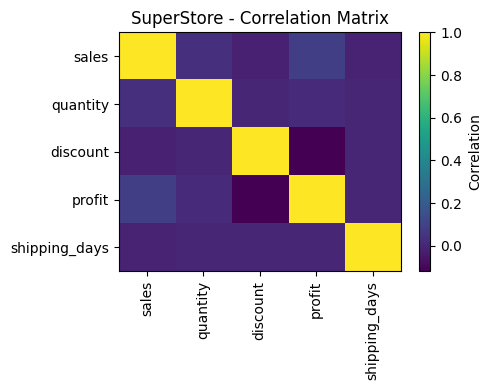

In [265]:
# Hagamos un mapa visual de las correlaciones

plt.figure(figsize=(5, 4))

plt.imshow(correlation, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation.columns)), correlation.columns,rotation=90)
plt.yticks(range(len(correlation.columns)),correlation.columns)
plt.title("SuperStore - Correlation Matrix")
plt.tight_layout()

plt.show()

Esto confirma visualmente los hallazgos de la tabla.

- **La diagonal principal** (Amarillo brillante): Como es de esperar en cualquier matriz de correlación, la diagonal principal muestra la correlación de cada variable consigo misma, alcanzando el valor máximo de 1.0. Esto sirve como referencia visual para calibrar el resto de los colores.

- **Descuento vs. Beneficio** (Mancha oscura): El gráfico destaca visualmente la relación más importante de todo el análisis. La intersección entre discount y profit aparece como un cuadrado de color morado oscuro, el más alejado del amarillo en toda la matriz. Aunque matemáticamente la correlación es débil (-0.12), visualmente es la relación más fuerte que existe entre dos variables diferentes. Este contraste visual subraya de inmediato que el descuento es el principal factor asociado a la caída del beneficio, confirmando la hipótesis que planteamos anteriormente.

- **Ventas y Beneficio** (Mancha ligeramente más clara): La intersección entre sales y profit muestra un tono ligeramente más claro que el fondo oscuro predominante. Esto refleja visualmente la débil correlación positiva (0.09) que ya habíamos detectado. El hecho de que no sea un color brillante (como el amarillo) indica que la relación es muy tenue.

- **Fondo** (morado oscuro): La gran mayoría de los cuadrados fuera de la diagonal son de un color morado oscuro casi uniforme. Esto indica visualmente que variables como quantity, shipping_days o sales con quantity no tienen una relación lineal significativa entre sí.

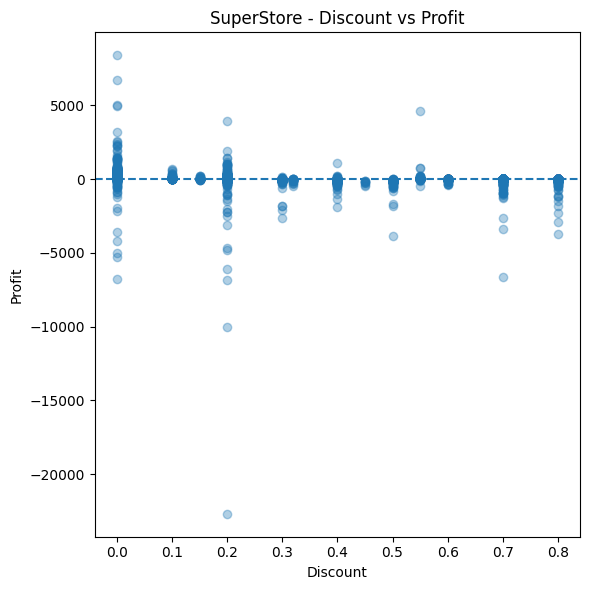

In [266]:
# Hagamos, entonces, un grádico de discount vs profit.
# La matriz de correlación nos dice si existe una asociación lineal, pero un scatter plot permite observar la estructura de los datos.

plt.figure(figsize=(6, 6))

plt.scatter(sales_detail["discount"], sales_detail["profit"], alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title("SuperStore - Discount vs Profit")
plt.xlabel("Discount"), plt.ylabel("Profit")
plt.tight_layout()

plt.show()

Notemos que:

- **Discount = 0.0:** La columna vertical de puntos en el eje $X = 0.0$ concentra la mayor densidad de pedidos. Aquí, la gran mayoría de los puntos se sitúan por encima de la línea de cero, confirmando que vender sin descuento es la principal fuente de beneficio. Sin embargo, incluso aquí existen puntos por debajo de cero, lo que indica que existen otros factores (como podrían ser costos de envío o devoluciones) que pueden generar pérdidas incluso sin descuentos.

- **Discount entre 0.1 y 0.2:** A medida que el descuento aumenta ligeramente, la nube de puntos comienza a descender. En el nivel 0.2 (20% de descuento), se observa una gran dispersión. Hay pedidos con beneficios positivos, pero también un número alarmante de puntos con pérdidas significativas. Destaca visualmente un valor atípico extremo (outlier) que cae por debajo de los -20,000 en beneficio, con un descuento del 20%.

- **Discount ≥ 0.3:** A partir del 30% de descuento, prácticamente la totalidad de los puntos se sitúan por debajo de la línea de cero. La empresa no está ganando dinero en estos pedidos. Visualmente, se confirma que el 30% es un punto de no retorno para la rentabilidad.

- **Discount ≥ 0.5:** En los niveles de descuento del 50%, 60%, 70% y 80%, los puntos son casi inexistentes por encima de la línea de beneficio. Todos los pedidos en estos rangos generan pérdidas.

In [267]:
# Ahora veamos el profit por banda de descuento

sales_detail["discount_band"] = pd.cut(sales_detail["discount"],
    bins=[-0.001, 0.10, 0.20, 0.30, 0.40, 0.50, 1.00],
    labels=["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50%+"])

discount_analysis = (sales_detail.groupby("discount_band", observed=False).agg(
        sales=("sales", "sum"),
        profit=("profit", "sum"),
        orders=("order_key", "nunique")
        ).reset_index()
)

discount_analysis["margin_percentage"] = (discount_analysis["profit"] / discount_analysis["sales"] * 100)

display(discount_analysis)

,discount_band,sales,profit,orders,margin_percentage
0,0-10%,"1,040,906.61","265,786.91",2738,25.53
1,10-20%,"739,912.78","7,897.75",2454,1.07
2,20-30%,"101,181.65","-18,276.81",213,-18.06
3,30-40%,"120,917.82","-21,480.13",212,-17.76
4,40-50%,"57,555.84","-21,458.92",73,-37.28
5,50%+,"96,300.39","-65,580.78",786,-68.10


El análisis de las bandas de descuento revela una transición hacia la pérdida de valor. Los datos evidencian que la empresa tiene un margen de maniobra muy estrecho y que su estrategia actual está fundamentalmente rota en los niveles altos de descuento.

- **0-10%:** Esta banda es el pilar del negocio. Genera el mayor volumen de ventas y concentra la inmensa mayoría del beneficio global con un margen del **25.53%**. Demuestra que la empresa es altamente rentable cuando vende a precio completo o con descuentos mínimos. Casi la mitad de los pedidos (2,738) se realizan en esta banda.

- **10-20%:** A pesar de que el volumen de ventas se mantiene muy alto y el número de pedidos es casi similar al de la banda anterior (2,454), el margen baja hasta el **1.07%**.

- **20% - 50%:** La empresa entra en números rojos. Todas las bandas superiores (20-30%, 30-40%, 40-50%) presentan márgenes negativos severos, oscilando entre el -17% y el -37%. Esto significa que, por cada dólar vendido en estas bandas, la empresa pierde dinero. El volumen de ventas en estas categorías es mucho menor, pero el daño al beneficio global es significativo.

- **50%+:** A pesar de representar solo \$96,300 en ventas, genera una pérdida de **-\$65,580.78**, con un margen negativo del **-68.10%**. Existen 786 pedidos que se realizaron con descuentos superiores al 50%, por lo que es imperativo investigar de inmediato qué productos, regiones o clientes están recibiendo estos descuentos extremos y por qué se están aprobando.

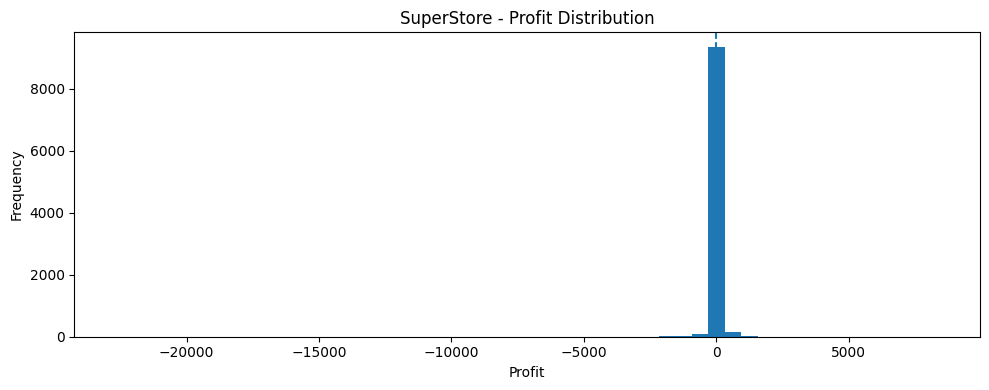

In [268]:
# Ahora, veamos la distribución del beneficio

plt.figure(figsize=(10, 4))

plt.hist(sales_detail["profit"].dropna(), bins=50)
plt.axvline(0, linestyle="--")
plt.title("SuperStore - Profit Distribution")
plt.xlabel("Profit"), plt.ylabel("Frequency")
plt.tight_layout()

plt.show()

El análisis de la distribución revela una alta concentración de datos en torno al punto de equilibrio, acompañada de una asimetría significativa hacia los valores negativos.

La distribución presenta una curva muy elevada en el punto de equilibrio, evidenciada por un pico máximo que supera los 8,000 registros en las proximidades de cero. Esto indica que la gran mayoría de las líneas de pedido generan un beneficio o pérdida marginal, muy cercano al punto de equilibrio.

También, debemos notar que la distribución no es simétrica. La cola derecha (beneficios positivos) se trunca rápidamente, sin registrar valores que superen los $\$5,000$. En contraste, la cola izquierda (pérdidas) se extiende de manera pronunciada, alcanzando valores negativos que superan los $-\$20,000$.

Además, la extensión de la cola izquierda indica que, aunque las pérdidas son menos frecuentes que los beneficios cercanos a cero, su magnitud es considerablemente mayor.

### **Estadística descriptiva**

El análisis de las medidas de tendencia central y dispersión permite obtener una visión integral de la estructura de los datos. Si bien la media aritmética es un indicador útil, resulta insuficiente para describir variables económicas y operativas que suelen presentar asimetrías y valores atípicos. Por ello, este análisis complementa la media con la mediana, la desviación estándar, los percentiles (25%, 50% y 75%) y los valores mínimo y máximo. Esta combinación proporciona una comprensión más robusta de la distribución de las variables clave del negocio: ventas, cantidad, descuento, beneficio y días de envío.



In [269]:
# Obtengamos entonces la estadística de nuestros datos
estadistica = (sales_detail[["sales",
            "quantity",
            "discount",
            "profit",
            "shipping_days"
        ]
    ].describe().T
)

display(estadistica)

,count,mean,std,min,25%,50%,75%,max
sales,"9,726.00",221.75,570.80,0.07,17.25,53.22,206.10,"22,638.48"
quantity,"10,006.00",6.83,34.13,1.00,2.00,3.00,5.00,720.00
discount,"10,194.00",0.16,0.21,0.00,0.00,0.20,0.20,0.80
profit,"9,696.00",15.15,389.97,"-22,679.88",1.68,8.58,29.15,"8,399.98"
shipping_days,"10,194.00",3.96,1.74,0.00,3.00,4.00,5.00,11.00


Notese que hay presencia de alta dispersión y asimetría en las métricas financieras y de volumen.

- **Ventas (sales):** La variable presenta una media de 221.75, significativamente superior a su mediana de 53.22. Esta diferencia evidencia una asimetría positiva pronunciada, donde un pequeño número de transacciones de gran volumen eleva el promedio general. La desviación estándar (570.80) es considerablemente alta en relación con la media, y el valor máximo (22,638.48) confirma la existencia de pedidos de gran magnitud que distorsionan la media. El 75% de las transacciones se sitúan por debajo de 206.10.

- **Cantidad (quantity):** Se observa un patrón similar de asimetría positiva. La media (6.83) duplica la mediana (3.00), lo que indica que la mayoría de los pedidos son de bajo volumen, pero existen casos excepcionales que elevan el promedio. El valor máximo registrado es de 720 unidades, un valor atípico extremo que, junto con una desviación estándar de 34.13, sugiere la necesidad de auditar pedidos mayoristas o posibles errores de registro.

- **Descuento (discount):** La distribución de los descuentos se concentra en valores bajos. La mediana y el percentil 75% se sitúan en 0.20 (20%), mientras que el percentil 25% es 0.00, lo que indica que al menos una cuarta parte de las transacciones no reciben descuento alguno. La media (0.16) es inferior a la mediana, lo que refleja una mayoría de descuentos moderados. Sin embargo, el valor máximo de 0.80 (80%) evidencia la existencia de políticas de descuento extremas que, como se analizó previamente, tienen un impacto directo en la rentabilidad.

- **Beneficio (profit):** Esta es la variable con mayor volatilidad y riesgo. La media (15.15) es superior a la mediana (8.58), pero la desviación estándar (389.97) es extraordinariamente alta, lo que indica una dispersión masiva de los resultados. El valor mínimo (-22,679.88) refleja pérdidas de gran magnitud, mientras que el máximo (8,399.98) muestra que los beneficios también pueden ser significativos. La diferencia entre el mínimo y el máximo, junto con el hecho de que el percentil 75% sea de solo 29.15, confirma que la distribución del beneficio está dominada por valores extremos negativos.

- **Días de envío (shipping_days):*+ En contraste con las variables anteriores, los días de envío presentan una distribución notablemente más estable y simétrica. La media (3.96) y la mediana (4.00) son prácticamente idénticas, y la desviación estándar (1.74) es relativamente baja. El rango de valores (0 a 11 días) es acotado, lo que indica un proceso logístico consistente y predecible en la mayoría de los casos.


Las variables financieras y de volumen (sales, quantity, profit) presentan una alta dispersión y asimetría, lo que implica que los promedios no son representativos del comportamiento típico del negocio.

In [270]:
# Verificamos los outliers
def detectar_outliers_iqr(dataframe, columna):
    """
    Identifica valores atípicos mediante el método IQR.

    Retorna:
        - DataFrame con outliers;
        - diccionario con límites y cuartiles.
    """
    datos = dataframe[columna].dropna()
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = (q1 - 1.5 * iqr)
    limite_superior = (q3 + 1.5 * iqr)

    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)].copy()
    limites = {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": limite_inferior,
        "upper_bound": limite_superior
    }
    return outliers, limites

In [271]:
outliers_sales, limites_sales = (detectar_outliers_iqr( sales_detail, "sales"))
outliers_profit, limites_profit = (detectar_outliers_iqr( sales_detail, "profit"))

outliers_quantity, limites_quantity = (detectar_outliers_iqr(sales_detail, "quantity"))

print("Outliers en Sales:", len(outliers_sales))
print("Outliers en Profit:", len(outliers_profit))
print("Outliers en Quantity:", len(outliers_quantity))

Outliers en Sales: 1129
Outliers en Profit: 1891
Outliers en Quantity: 277


La presencia de un número elevado de valores atípicos en las variables de beneficio y ventas tiene implicaciones directas en la interpretación de los datos.

En primer lugar, valida la decisión metodológica de utilizar la mediana como medida de tendencia central preferente sobre la media aritmética, ya que esta última se ve distorsionada por los valores extremos.

En segundo lugar, la alta incidencia de outliers en el beneficio (casi 1,900 casos) indica que los resultados financieros de la empresa no son homogéneos, sino que dependen de un grupo de transacciones con un comportamiento financiero altamente volátil.

Se recomienda realizar una auditoría específica sobre estos valores atípicos para determinar si corresponden a errores de registro, a pedidos estratégicos de gran volumen con márgenes excepcionales, o a transacciones con pérdidas severas que requieran una revisión de la política comercial.

In [272]:
# Veamos los cuadrantes sales vs profit

mediana_sales_product = (product["sales"].median())
mediana_profit_product = (product["profit"].median())

product_quadrants = (product.copy())
product_quadrants["quadrant"] = np.select([(product_quadrants["sales"] >= mediana_sales_product)
        & (product_quadrants["profit"] >= mediana_profit_product),
        (product_quadrants["sales"] >= mediana_sales_product)
        &
        (product_quadrants["profit"] < mediana_profit_product),
        (product_quadrants["sales"] < mediana_sales_product)
        &
        (product_quadrants["profit"] >= mediana_profit_product)
    ],
    ["High Sales / High Profit", "High Sales / Low Profit", "Low Sales / High Profit"],
    default="Low Sales / Low Profit"
)

display(product_quadrants[["product_name", "sales", "profit", "quadrant"]].head(20))

,product_name,sales,profit,quadrant
787,Fellowes PB500 Electric Punch Plastic Comb Bin...,"27,453.38","7,753.04",High Sales / High Profit
1669,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08",High Sales / Low Profit
1640,Canon imageCLASS 2200 Advanced Copier,"19,599.94","25,199.93",High Sales / High Profit
667,GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50",760.98,High Sales / High Profit
1630,Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88",High Sales / High Profit
82,HON 5400 Series Task Chairs for Big and Tall,"18,365.68",0.00,High Sales / Low Profit
858,GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17",High Sales / Low Profit
1465,Martin Yale Chadless Opener Electric Letter Op...,"16,656.20","-1,299.18",High Sales / Low Profit
692,Ibico EPK-21 Electric Binding System,"15,875.92","-20,978.89",High Sales / Low Profit
1657,HP Designjet T520 Inkjet Large Format Printer ...,"15,749.91","2,239.99",High Sales / High Profit


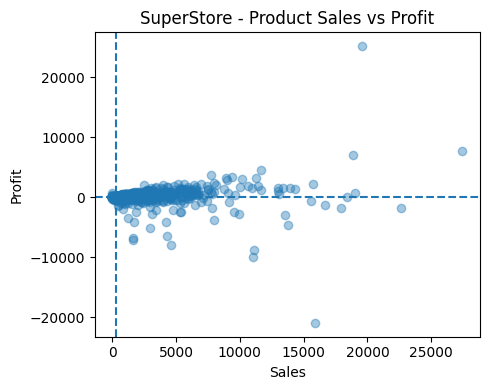

In [273]:
# Grafiquemos estos datos

plt.figure(figsize=(5, 4))

plt.scatter(product_quadrants["sales"], product_quadrants["profit"], alpha=0.4)
plt.axvline(mediana_sales_product, linestyle="--")
plt.axhline(mediana_profit_product, linestyle="--")
plt.title("SuperStore - Product Sales vs Profit")
plt.xlabel("Sales"), plt.ylabel("Profit")
plt.tight_layout()

plt.show()

Notemos que:

- **High Sales / High Profit**: Este cuadrante agrupa los productos que generan un alto volumen de ventas y, simultáneamente, un beneficio superior a la mediana. Destacan casos como el **Canon imageCLASS 2200 Advanced Copier**, que con \$19,599.94 en ventas genera **\$25,199.93** en beneficio, posicionándose como el producto más rentable del catálogo. Le siguen el **Fellowes PB500 Electric Punch** y el **Hewlett Packard LaserJet 3310 Copier**. Estos productos representan el núcleo estratégico del negocio, ya que contribuyen de manera significativa tanto a los ingresos como a la rentabilidad.

- **High Sales / Low Profit** (Productos de Alto Volumen con Baja Rentabilidad): Este cuadrante contiene productos que, a pesar de tener un volumen de ventas considerable, presentan un beneficio inferior a la mediana, e incluso negativo. El caso más representativo es el **Ibico EPK-21 Electric Binding System**, que con \$15,875.92 en ventas registra una pérdida de **-\$20,978.89**. Asimismo, el **Cisco TelePresence System EX90** y el **GBC DocuBind P400** evidencian que existen productos de alta rotación que están destruyendo valor. La presencia de estos artículos en el catálogo requiere una revisión inmediata de su estructura de costos, precios o políticas de descuento asociadas.

- **Low Sales / High Profit** (Productos de Nicho Rentable): Aunque no aparecen de forma predominante en el top 20 de ventas, el gráfico de dispersión evidencia la existencia de un conjunto de productos con bajo volumen de facturación pero con márgenes de beneficio elevados. Estos artículos, como el **Apple iPhone 5** o el **Samsung Galaxy Mega 6.3**, representan oportunidades de nicho que, si bien no impulsan el volumen global, contribuyen positivamente al margen de la empresa. Su gestión debe orientarse a mantener su disponibilidad y a explorar estrategias de venta cruzada para aumentar su rotación sin sacrificar su rentabilidad.

- **Low Sales / Low Profit** (Cola Larga del Catálogo): La mayor concentración de puntos en el gráfico de dispersión se ubica en el cuadrante inferior izquierdo. Esto indica que la mayoría de los productos del catálogo generan ventas y beneficios por debajo de la mediana. Esta "cola larga" representa una complejidad operativa significativa (gestión de inventario, logística, almacenamiento) para un retorno económico marginal.

Ahora, haremos un análisis RFM para estudiar el comportamiento de la base de clientes a partir de tres dimensiones fundamentales: la recencia (`recency`), que mide los días transcurridos desde la última compra; la frecuencia (`frequency`), que cuantifica el número de pedidos únicos realizados; y el valor monetario (`monetary`), que suma el total de ventas generado por cada cliente.

Para su cálculo, se estableció como fecha de referencia el día posterior a la última fecha de pedido observada en el conjunto de datos, con el fin de estandarizar el cálculo de la recencia. Es importante señalar que este análisis es de carácter descriptivo y no constituye un modelo predictivo de Customer Lifetime Value (CLV), sino una herramienta para perfilar la cartera de clientes actual.

In [274]:
# Fecha de referencia:
# un día después de la última fecha observada.
fecha_referencia = (sales_detail["order_date"].max() + pd.Timedelta(days=1))
rfm = (sales_detail.groupby(["customer_id", "customer_name"]).agg(
        recency=("order_date", lambda fechas:( fecha_referencia - fechas.max()).days),
        frequency=("order_key", "nunique"),
        monetary=("sales", "sum")
        ).reset_index()
)

display(rfm.head(20))

,customer_id,customer_name,recency,frequency,monetary
0,AA-10315,Alex Avila,185,5,"1,633.49"
1,AA-10375,Allen Armold,20,9,"1,056.39"
2,AA-10480,Andrew Allen,260,4,"1,782.97"
3,AA-10645,Anna Andreadi,56,6,"5,086.93"
4,AB-10015,Aaron Bergman,416,3,886.16
5,AB-10060,Adam Bellavance,55,8,"7,587.68"
6,AB-10105,Adrian Barton,42,10,"14,455.39"
7,AB-10150,Aimee Bixby,42,5,966.71
8,AB-10165,Alan Barnes,11,10,"1,223.11"
9,AB-10255,Alejandro Ballentine,167,9,914.53


Una vez calculadas las métricas brutas de recencia, frecuencia y monetario, el siguiente paso metodológico consiste en transformarlas en una escala ordinal que permita su comparación y agregación. Para ello, cada variable fue dividida en cuatro cuartiles mediante la función qcut, asignando una puntuación de 1 a 4 en función de la posición relativa de cada cliente. Se aplicó previamente un ordenamiento con `rank(method="first")` para evitar conflictos en los límites de los cuartiles cuando múltiples clientes comparten valores idénticos.

La orientación de las puntuaciones se definió según la naturaleza de cada variable: en recencia, un menor número de días implica una puntuación más alta (4); en frecuencia y monetario, un mayor valor implica una puntuación más alta (4). Finalmente, se calculó una puntuación RFM agregada como la suma de las tres dimensiones, cuyo rango teórico se sitúa entre 3 y 12 puntos.

In [275]:
# RECENCY
rfm["R_score"] = pd.qcut(rfm["recency"].rank( method="first"), 4, labels=[4, 3, 2, 1])

# FREQUENCY
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[4, 3, 2, 1])

# MONETARY
rfm["M_score"] = pd.qcut(rfm["monetary"].rank( method="first"), 4, labels=[4, 3, 2, 1])

# RFM completo

rfm["RFM_score"] = (rfm["R_score"].astype(int) + rfm["F_score"].astype(int) + rfm["M_score"].astype(int))
rfm = rfm.sort_values("RFM_score", ascending=False)

display(rfm.head(20))


,customer_id,customer_name,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
20,AG-10330,Alex Grayson,9,5,660.97,4,4,4,12
704,SK-19990,Sally Knutson,9,3,883.41,4,4,4,12
666,RS-19870,Roy Skaria,20,2,22.33,4,4,4,12
662,RR-19315,Ralph Ritter,20,2,538.21,4,4,4,12
589,PB-18805,Patrick Bzostek,26,3,740.36,4,4,4,12
33,AH-10585,Angele Hood,22,4,738.50,4,4,4,12
481,LT-16765,Larry Tron,27,3,329.88,4,4,4,12
215,DK-13150,David Kendrick,11,2,797.83,4,4,4,12
72,BD-11635,Brian Derr,10,3,185.60,4,4,4,12
320,HE-14800,Harold Engle,13,4,883.53,4,4,4,12


La ordenación descendente por RFM_score permite identificar el segmento de clientes con la puntuación más alta dentro de la escala ordinal construida. La tabla presenta los 20 clientes con mayor puntuación, cuyo perfil se caracteriza por combinar los tres atributos de máximo valor: actividad reciente, frecuencia de compra elevada y contribución monetaria superior.

Lo más relevante es que diecinueve de los veinte clientes listados alcanzan una puntuación RFM de 12, lo que corresponde a R=4, F=4 y M=4. Esto indica que estos clientes se sitúan en el cuartil superior en las tres dimensiones simultáneamente. Únicamente Peter Bühler (posición 20) presenta una puntuación de 11, como resultado de un R_score=3 (recencia de 58 días), manteniendo F=4 y M=4.

- **Recency:** El rango de días desde la última compra en este segmento oscila entre 1 y 58 días. Destacan casos de actividad inmediata como Harry Olson (1 día), Greg Hansen (3 días) y Jennifer Halladay (6 días). Los valores más altos del grupo corresponden a Peter Bühler (58 días) y Clay Cheatham (28 días), lo que explica la asignación de `R_score=3` para el primero. En conjunto, la recencia es significativamente inferior a la mediana general, confirmando que se trata de clientes con vinculación vigente.

- **Frequency:** El número de pedidos únicos en este segmento se sitúa entre 2 y 5. Los clientes con mayor recurrencia son Alex Grayson (5 pedidos), seguido por un grupo con 4 pedidos que incluye a Jennifer Halladay, Harry Olson, Andy Yotov, Anthony Witt, Brad Norvell y Peter Bühler. Es relevante observar que, si bien estos clientes ocupan el cuartil superior en frecuencia, el número absoluto de pedidos es moderado, lo que sugiere que la distribución general de la frecuencia es compacta y con valores bajos.

- **Monetary:** El valor acumulado de ventas en este segmento oscila entre $\$22.33$ (Roy Skaria) y $\$944.22$ (Harry Olson). Este hallazgo es particularmente significativo ya que los clientes con la puntuación RFM más alta del conjunto de datos presentan valores monetarios que, en términos absolutos, no son elevados. La coincidencia de un `M_score=4` con valores inferiores a $\$1,000$ indica que el cuartil superior de la variable monetaria se sitúa en un umbral relativamente bajo, lo que refleja una base de clientes con un gasto promedio reducido.


También podríamos ver y analizar los clientes con peores puntuaciones, pero lo dejaré para que cualquier persona interesada quiera hacerlo después.

# **Resumen Ejecutivo**
Tras el desarrollo de los análisis parciales por país, estado, ciudad, logística, descuentos, productos y clientes, esta sección tiene como propósito sintetizar los hallazgos principales del estudio. Es importante señalar que este resumen no sustituye la interpretación humana de los datos, sino que constituye una primera lectura automatizada, generada exclusivamente a partir de los valores agregados del conjunto de datos. Su función es proporcionar una visión consolidada y de alto nivel que sirva como punto de partida para la toma de decisiones estratégicas.

In [276]:
# Definimos los KPIs globales
kpis_globales = pd.DataFrame({"Métrica": [
        "Ventas totales",
        "Beneficio total",
        "Margen global",
        "Pedidos únicos",
        "Clientes únicos"],
    "Valor": [
        f"${sales_detail['sales'].sum():,.2f}",
        f"${sales_detail['profit'].sum():,.2f}",
        f"{sales_detail['profit'].sum() / sales_detail['sales'].sum() * 100:.2f}%",
        f"{sales_detail['order_key'].nunique():,}",
        f"{sales_detail['customer_id'].nunique():,}"
    ]
})

# Definimos los datos que hemos encontrado a lo largo del análisis
hallazgos = pd.DataFrame([
    ["Categoría líder por ventas",              categoria_lider_ventas["category"],       "positivo"],
    ["Categoría líder por beneficio",           categoria_lider_profit["category"],       "positivo"],
    ["Categoría con peor beneficio",            categoria_peor_profit["category"],        "negativo"],
    ["Región líder por ventas",                 region_lider["region"],                   "positivo"],
    ["Producto líder por ventas",               producto_lider_ventas["product_name"],    "positivo"],
    ["Producto líder por beneficio",            producto_lider_profit["product_name"],    "positivo"],
    ["Cliente líder por ventas",                cliente_lider["customer_name"],           "positivo"],
    ["Subcategoría líder por ventas",           subcategoria_lider["sub_category"],       "positivo"],
    ["Subcategoría con peor beneficio",         subcategoria_peor_profit["sub_category"], "negativo"],
    ["Ship Mode más utilizado",                 ship_mode_mas_utilizado["ship_mode"],     "neutro"],
    ["Ship Mode con mayor tiempo promedio",     ship_mode_mas_lento["ship_mode"],         "neutro"],
], columns=["Dimensión", "Hallazgo", "Tipo"])

# Especificamos el estilo
estilo_kpi = (
    kpis_globales.style
    .set_properties(**{
        "text-align": "left",
        "font-size": "13px",
        "padding": "8px"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#1F3864"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "left"),
            ("padding", "10px"),
            ("font-size", "13px")
        ]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#F2F5FA")]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse"),
            ("width", "60%")
        ]}
    ])
    .hide(axis="index")
)

def color_hallazgo(val):
    if val == "positivo":
        return "background-color: #D9EAD3; color: #1E5631; font-weight: bold;"
    elif val == "negativo":
        return "background-color: #F4CCCC; color: #7F1D1D; font-weight: bold;"
    else:
        return "background-color: #FFF2CC; color: #7F6000; font-weight: bold;"

estilo_hallazgos = (
    hallazgos.style
    .map(color_hallazgo, subset=["Tipo"])
    .set_properties(**{
        "text-align": "left",
        "font-size": "13px",
        "padding": "8px"
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("background-color", "#1F3864"),
            ("color", "white"),
            ("font-weight", "bold"),
            ("text-align", "left"),
            ("padding", "10px"),
            ("font-size", "13px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse"),
            ("width", "90%")
        ]}
    ])
    .hide(axis="index")
    .hide(axis="columns", subset=["Tipo"])
)

# Graficamos
from IPython.display import display, HTML

display(HTML(
    "<h2 style='font-family: Segoe UI, sans-serif; color:#1F3864;"
    "border-bottom: 2px solid #1F3864; padding-bottom: 6px;'>"
    "SuperStore Analytics — Resumen Ejecutivo</h2>"
))

display(HTML(
    "<h3 style='font-family: Segoe UI, sans-serif; color:#1F3864;'>"
    "Indicadores Globales</h3>"
))
display(estilo_kpi)

display(HTML(
    "<h3 style='font-family: Segoe UI, sans-serif; color:#1F3864;'>"
    "Hallazgos por Dimensión</h3>"
))
display(estilo_hallazgos)

Métrica,Valor
Ventas totales,"$2,156,775.10"
Beneficio total,"$146,888.02"
Margen global,6.81%
Pedidos únicos,"5,113"
Clientes únicos,800


Dimensión,Hallazgo
Categoría líder por ventas,Technology
Categoría líder por beneficio,Technology
Categoría con peor beneficio,Furniture
Región líder por ventas,West
Producto líder por ventas,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind
Producto líder por beneficio,Canon imageCLASS 2200 Advanced Copier
Cliente líder por ventas,Sean Miller
Subcategoría líder por ventas,Phones
Subcategoría con peor beneficio,Tables
Ship Mode más utilizado,Standard Class
